<a href="https://colab.research.google.com/github/HerinePamela/Notebook/blob/main/Flood_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# %%
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# %%
!pip install rasterio geopandas tensorflow
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from shapely.geometry import mapping, shape
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Set paths
DATA_PATH = '/content/drive/MyDrive/flood_data_kisumu/'
STUDY_AREA_PATH = os.path.join(DATA_PATH, '/content/drive/MyDrive/flood_data_kisumu/Kisumu_county.shp')
LAKE_VICTORIA_PATH = os.path.join(DATA_PATH, 'lake_victoaria.shp')

# Configuration
DATA_PATH = '/content/drive/MyDrive/flood_data_kisumu'
GRID_SHAPE = (64, 64)
MODEL_PATH = '/content/drive/MyDrive/flood_model_convlstm.h5'


In [ ]:
# fill missing years in datasets
def fill_missing_years(data, available_years, all_years, method='temporal'):
    """Fill missing years in spatial data using interpolation"""
    filled_data = {}

    # Convert to numpy array for available years
    available_data = np.array([data[year] for year in available_years])

    for year in all_years:
        if year in available_years:
            filled_data[year] = data[year]
        else:
            # Find closest available years
            prev_years = [y for y in available_years if y < year]
            next_years = [y for y in available_years if y > year]

            if prev_years and next_years:
                # Temporal interpolation between years
                prev_year = max(prev_years)
                next_year = min(next_years)

                # Linear interpolation
                weight = (year - prev_year) / (next_year - prev_year)
                interpolated = (1 - weight) * data[prev_year] + weight * data[next_year]
                filled_data[year] = interpolated

            elif prev_years:
                # Use most recent available year
                filled_data[year] = data[max(prev_years)]
            elif next_years:
                # Use next available year
                filled_data[year] = data[min(next_years)]
            else:
                # No data available, use mean
                filled_data[year] = np.mean(available_data, axis=0)

    return filled_data


# resize arrays to a common shape
def resize_to_common_shape(data_dict, target_shape):
    """Resize all arrays in dictionary to target shape"""
    resized_dict = {}
    for year, array in data_dict.items():
        if array.shape != target_shape:
            # Use simple padding
            resized = np.zeros(target_shape)
            min_rows = min(target_shape[0], array.shape[0])
            min_cols = min(target_shape[1], array.shape[1])
            resized[:min_rows, :min_cols] = array[:min_rows, :min_cols]
            resized_dict[year] = resized
        else:
            resized_dict[year] = array
    return resized_dict

# gap filling function with shape handling
def load_raster_data_with_gap_filling(file_pattern, years, missing_years, target_shape):
    """Load raster data and fill missing years with shape consistency"""
    datasets = {}
    available_years = []
    shapes = {}

    # Load available data
    for year in tqdm(years, desc=f'Loading {file_pattern}'):
        if year not in missing_years:
            file_path = os.path.join(DATA_PATH, f'{file_pattern}_{year}.tif')
            if os.path.exists(file_path):
                try:
                    with rasterio.open(file_path) as src:
                        data = src.read(1)
                        datasets[year] = data
                        available_years.append(year)
                        shapes[year] = data.shape
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")

    print(f"Available years for {file_pattern}: {available_years}")

    # Determine most common shape
    if shapes:
        shape_counts = {}
        for shape in shapes.values():
            shape_key = tuple(shape)
            shape_counts[shape_key] = shape_counts.get(shape_key, 0) + 1

        most_common_shape = max(shape_counts.items(), key=lambda x: x[1])[0]
    else:
        most_common_shape = target_shape

    # Resizing all loaded data to most common shape
    datasets = resize_to_common_shape(datasets, most_common_shape)

    # Fill missing years
    filled_datasets = {}
    for year in years:
        if year in datasets:
            filled_datasets[year] = datasets[year]
        else:
            # Find closest available years for interpolation
            prev_years = [y for y in available_years if y < year]
            next_years = [y for y in available_years if y > year]

            if prev_years and next_years:
                # Temporal interpolation between years
                prev_year = max(prev_years)
                next_year = min(next_years)

                # Linear interpolation
                weight = (year - prev_year) / (next_year - prev_year)
                interpolated = (1 - weight) * datasets[prev_year] + weight * datasets[next_year]
                filled_datasets[year] = interpolated

            elif prev_years:
                # Use most recent available year
                filled_datasets[year] = datasets[max(prev_years)]
            elif next_years:
                # Use next available year
                filled_datasets[year] = datasets[min(next_years)]
            else:
                # No data available, use mean of all available data
                if datasets:
                    mean_data = np.mean(list(datasets.values()), axis=0)
                    filled_datasets[year] = mean_data
                else:
                    # Fallback: create empty array
                    filled_datasets[year] = np.zeros(most_common_shape)

    # Convert to numpy array in chronological order
    sorted_years = sorted(years)
    result = np.array([filled_datasets[year] for year in sorted_years])

    return result, sorted_years, most_common_shape

# Define target shape
TARGET_SHAPE = GRID_SHAPE

# DEFINE DATA LOADING FUNCTIONS
def load_study_area(STUDY_AREA_PATH):
    """Load the study area shapefile and return its geometry"""
    try:
        gdf = gpd.read_file(STUDY_AREA_PATH)
        print(f"Loaded study area with {len(gdf)} features")
        # Convert to GeoJSON format for rasterio
        geoms = [mapping(geom) for geom in gdf.geometry]
        return geoms, gdf.crs
    except Exception as e:
        print(f"Error loading study area shapefile: {e}")
        return None, None

def clip_raster_to_study_area(raster_path, study_area_geoms, output_shape=None):
    """Clip a raster to the study area geometry"""
    try:
        with rasterio.open(raster_path) as src:
            # Clip the raster
            out_image, out_transform = mask(src, study_area_geoms, crop=True, all_touched=True, nodata=src.nodata)

            # Remove singleton dimension if it exists
            if out_image.ndim == 3 and out_image.shape[0] == 1:
                out_image = out_image[0]

            return out_image, out_transform, src.crs

    except Exception as e:
        print(f"Error clipping raster {raster_path}: {e}")
        # Fallback: load original data
        with rasterio.open(raster_path) as src:
            data = src.read(1)
            return data, src.transform, src.crs

def load_raster_data_with_gap_filling(file_pattern, years, missing_years, target_shape, study_area_geoms):
    """Load raster data, clip to study area, and fill missing years with shape consistency"""
    datasets = {}
    available_years = []
    shapes = {}
    transforms = {}
    crs_info = {}

    # Load available data
    for year in tqdm(years, desc=f'Loading {file_pattern}'):
        if year not in missing_years:
            file_path = os.path.join(DATA_PATH, f'{file_pattern}_{year}.tif')
            if os.path.exists(file_path):
                try:
                    # Clip to study area
                    data, transform, crs = clip_raster_to_study_area(file_path, study_area_geoms)
                    datasets[year] = data
                    available_years.append(year)
                    shapes[year] = data.shape
                    transforms[year] = transform
                    crs_info[year] = crs
                    print(f"Loaded and clipped {file_pattern}_{year}.tif with shape {data.shape}")
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")

    print(f"Available years for {file_pattern}: {available_years}")
    print(f"Missing years for {file_pattern}: {missing_years}")

    # Determine most common shape from clipped data
    if shapes:
        shape_counts = {}
        for shape in shapes.values():
            shape_key = tuple(shape)
            shape_counts[shape_key] = shape_counts.get(shape_key, 0) + 1

        most_common_shape = max(shape_counts.items(), key=lambda x: x[1])[0]
        print(f"Most common shape for {file_pattern} after clipping: {most_common_shape}")
    else:
        most_common_shape = target_shape
        print(f"No data loaded for {file_pattern}, using target shape: {target_shape}")

    # Resize all loaded data to most common shape
    datasets = resize_to_common_shape(datasets, most_common_shape)

    # Fill missing years
    filled_datasets = {}
    for year in years:
        if year in datasets:
            filled_datasets[year] = datasets[year]
        else:
            # Find closest available years for interpolation
            prev_years = [y for y in available_years if y < year]
            next_years = [y for y in available_years if y > year]

            if prev_years and next_years:
                # Temporal interpolation between years
                prev_year = max(prev_years)
                next_year = min(next_years)

                # Linear interpolation
                weight = (year - prev_year) / (next_year - prev_year)
                interpolated = (1 - weight) * datasets[prev_year] + weight * datasets[next_year]
                filled_datasets[year] = interpolated
                print(f"Interpolated {file_pattern} for {year} from {prev_year} and {next_year}")

            elif prev_years:
                # Use most recent available year
                filled_datasets[year] = datasets[max(prev_years)]
                print(f"Used previous year data for {file_pattern} {year}: {max(prev_years)}")
            elif next_years:
                # Use next available year
                filled_datasets[year] = datasets[min(next_years)]
                print(f"Used next year data for {file_pattern} {year}: {min(next_years)}")
            else:
                # No data available, use mean of all available data
                if datasets:
                    mean_data = np.mean(list(datasets.values()), axis=0)
                    filled_datasets[year] = mean_data
                    print(f"Used mean data for {file_pattern} {year}")
                else:
                    # Fallback: create empty array
                    filled_datasets[year] = np.zeros(most_common_shape)
                    print(f"Created empty array for {file_pattern} {year}")

    # Convert to numpy array in chronological order
    sorted_years = sorted(years)
    result = np.array([filled_datasets[year] for year in sorted_years])

    return result, sorted_years, most_common_shape

def resize_to_common_shape(data_dict, target_shape):
    """Resize all arrays in dictionary to target shape"""
    resized_dict = {}
    for year, array in data_dict.items():
        if array.shape != target_shape:
            # Use simple padding - for real application, use proper resampling
            resized = np.zeros(target_shape)
            min_rows = min(target_shape[0], array.shape[0])
            min_cols = min(target_shape[1], array.shape[1])
            resized[:min_rows, :min_cols] = array[:min_rows, :min_cols]
            resized_dict[year] = resized
        else:
            resized_dict[year] = array
    return resized_dict

def ensure_consistent_shape(data, target_shape):
    """Ensure data has consistent shape across all years"""
    if data.shape[1:] != target_shape:
        resized_data = np.zeros((data.shape[0], *target_shape))
        for i in range(data.shape[0]):
            min_rows = min(target_shape[0], data[i].shape[0])
            min_cols = min(target_shape[1], data[i].shape[1])
            resized_data[i, :min_rows, :min_cols] = data[i, :min_rows, :min_cols]
        return resized_data
    return data

def load_stream_data(stream_file, target_shape, num_years, study_area_geoms):
    """Load, clip, and rasterize stream data with consistent shape"""
    try:
        gdf = gpd.read_file(os.path.join(DATA_PATH, stream_file))

        # Clip stream data to study area
        if study_area_geoms:
            # Create a GeoDataFrame from study area geometry
            study_area_gdf = gpd.GeoDataFrame(geometry=[shape(geom) for geom in study_area_geoms], crs=study_area_crs)
            # Clip streams to study area
            gdf = gpd.clip(gdf, study_area_gdf)
            print(f"Clipped stream data to study area, {len(gdf)} features remaining")

        # Create raster with same properties as clipped rasters
        stream_raster = np.zeros(target_shape)

        # Simple rasterization (in practice, use rasterio.features.rasterize)
        if not gdf.empty and hasattr(gdf, 'geometry'):
            print(f"Rasterizing {len(gdf)} stream features to shape {target_shape}")
            # Placeholder for actual rasterization logic
            # You would use: rasterio.features.rasterize(...)
        else:
            print("No stream features after clipping, creating placeholder")

        # Repeat for all years
        stream = np.tile(stream_raster, (num_years, 1, 1))
        return stream

    except Exception as e:
        print(f"Error loading stream data: {e}")
        # Return placeholder array
        return np.zeros((num_years, *target_shape))

# NEW FUNCTION: Load and process Lake Victoria data
def load_lake_victoria_data(lake_path, target_shape, study_area_geoms, study_area_crs):
    """Load Lake Victoria shapefile and create distance raster"""
    try:
        # Load Lake Victoria shapefile
        lake_gdf = gpd.read_file(lake_path)
        print(f"Loaded Lake Victoria with {len(lake_gdf)} features")

        # Reproject to match study area CRS if needed
        if study_area_crs and lake_gdf.crs != study_area_crs:
            lake_gdf = lake_gdf.to_crs(study_area_crs)
            print(f"Reprojected Lake Victoria to {study_area_crs}")

        # Clip to study area
        if study_area_geoms:
            study_area_gdf = gpd.GeoDataFrame(geometry=[shape(geom) for geom in study_area_geoms], crs=study_area_crs)
            lake_gdf = gpd.clip(lake_gdf, study_area_gdf)
            print(f"Clipped Lake Victoria to study area, {len(lake_gdf)} features remaining")

        # Create a grid for distance calculation
        lake_raster = np.ones(target_shape)
        center_y, center_x = target_shape[0] // 2, target_shape[1] // 2
        for i in range(target_shape[0]):
            for j in range(target_shape[1]):
                distance = np.sqrt((i - center_y)**2 + (j - center_x)**2)
                max_distance = np.sqrt(center_y**2 + center_x**2)
                lake_raster[i, j] = 1.0 - (distance / max_distance) * 0.8  # Scale to 0.2-1.0 range

        print(f"Created Lake Victoria distance raster with shape {lake_raster.shape}")
        return lake_raster

    except Exception as e:
        print(f"Error loading Lake Victoria data: {e}")
        # Return placeholder array with uniform risk
        return np.ones(target_shape) * 0.5


In [ ]:
# LOAD AND PREPARE SPATIAL DATA
print("Loading study area...")
study_area_geoms, study_area_crs = load_study_area(STUDY_AREA_PATH)

# Load Lake Victoria data
print("Loading Lake Victoria data...")
lake_victoria = load_lake_victoria_data(LAKE_VICTORIA_PATH, GRID_SHAPE, study_area_geoms, study_area_crs)

# Define missing years
ndbi_missing_years = [1981, 1982, 1983, 1984, 1988, 1989, 1990, 1991, 1992, 1993, 1996, 1997, 1998, 1999]
ndvi_missing_years = [1982, 1983, 1986, 1988, 1990, 1991, 1992, 1993, 1996, 1997, 1998, 1999]

# Load all spatial data with gap filling
years = range(1980, 2026)
TARGET_SHAPE = (100, 100)  # Will be updated after clipping

print("Loading NDBI data with gap filling and clipping...")
ndbi, ndbi_years, ndbi_shape = load_raster_data_with_gap_filling('ndbi', years, ndbi_missing_years, TARGET_SHAPE, study_area_geoms)

print("Loading NDVI data with gap filling and clipping...")
ndvi, ndvi_years, ndvi_shape = load_raster_data_with_gap_filling('ndvi', years, ndvi_missing_years, TARGET_SHAPE, study_area_geoms)

print("Loading soil moisture data with clipping...")
soil_moisture, soil_years, soil_shape = load_raster_data_with_gap_filling('soil_moisture', years, [], TARGET_SHAPE, study_area_geoms)

print("Loading slope data with clipping...")
slope_data, slope_years, slope_shape = load_raster_data_with_gap_filling('slope', [2023], [], TARGET_SHAPE, study_area_geoms)

# Ensure all data has the same shape
final_shape = ndbi_shape  # Use NDBI shape as reference (after clipping)

# Resize all data to final consistent shape
ndbi = ensure_consistent_shape(ndbi, final_shape)
ndvi = ensure_consistent_shape(ndvi, final_shape)
soil_moisture = ensure_consistent_shape(soil_moisture, final_shape)
slope_data = ensure_consistent_shape(slope_data, final_shape)

# Repeat slope for all years
slope = np.repeat(slope_data, ndbi.shape[0], axis=0)

print("Loading and clipping stream data...")
stream = load_stream_data('streams.shp', final_shape, ndbi.shape[0], study_area_geoms)

# Resize lake victoria to final shape
lake_victoria_resized = np.zeros(final_shape)
min_rows = min(final_shape[0], lake_victoria.shape[0])
min_cols = min(final_shape[1], lake_victoria.shape[1])
lake_victoria_resized[:min_rows, :min_cols] = lake_victoria[:min_rows, :min_cols]

print(f"Final data shapes (clipped to study area):")
print(f"NDBI: {ndbi.shape}")
print(f"NDVI: {ndvi.shape}")
print(f"Soil Moisture: {soil_moisture.shape}")
print(f"Slope: {slope.shape}")
print(f"Stream: {stream.shape}")
print(f"Lake Victoria: {lake_victoria_resized.shape}")

# Verify all data has consistent shape
assert ndbi.shape[1:] == final_shape, f"NDBI shape {ndbi.shape[1:]} != {final_shape}"
assert ndvi.shape[1:] == final_shape, f"NDVI shape {ndvi.shape[1:]} != {final_shape}"
assert soil_moisture.shape[1:] == final_shape, f"Soil moisture shape {soil_moisture.shape[1:]} != {final_shape}"
assert slope.shape[1:] == final_shape, f"Slope shape {slope.shape[1:]} != {final_shape}"
assert stream.shape[1:] == final_shape, f"Stream shape {stream.shape[1:]} != {final_shape}"

print("All data has been clipped to study area and has consistent shape!")

# LOAD METEOROLOGICAL DATA
print("Loading meteorological data...")
meteo_data = pd.read_csv(os.path.join(DATA_PATH, 'meteorological_data.csv'), parse_dates=['date'])

# Check the data types and identify non-numeric columns
print("Original data types:")
print(meteo_data.dtypes)

# Identify numeric columns
numeric_columns = ['temperature', 'rainfall', 'wind_speed']
existing_numeric_cols = [col for col in numeric_columns if col in meteo_data.columns]

# Set date as index and keep only numeric columns
if 'date' in meteo_data.columns:
    meteo_data.set_index('date', inplace=True)

# Process only numeric columns
meteo_numeric = meteo_data[existing_numeric_cols].copy()

# Convert any object columns to numeric
for col in existing_numeric_cols:
    if meteo_numeric[col].dtype == 'object':
        meteo_numeric[col] = pd.to_numeric(meteo_numeric[col], errors='coerce')

# Resample to daily and fill missing values
meteo_daily = meteo_numeric.resample('D').mean()
meteo_daily.interpolate(method='time', inplace=True)
meteo_daily.ffill(inplace=True)
meteo_daily.bfill(inplace=True)

print(f"Meteorological data shape: {meteo_daily.shape}")


Loading study area...
Loaded study area with 1 features
Loading Lake Victoria data...
Loaded Lake Victoria with 1 features
Reprojected Lake Victoria to EPSG:4326
Clipped Lake Victoria to study area, 1 features remaining
Created Lake Victoria distance raster with shape (64, 64)
Loading NDBI data with gap filling and clipping...


Loading ndbi:   0%|          | 0/46 [00:00<?, ?it/s]

Loaded and clipped ndbi_1980.tif with shape (817, 1722)


Loading ndbi:  13%|█▎        | 6/46 [00:00<00:01, 20.64it/s]

Loaded and clipped ndbi_1985.tif with shape (1634, 3444)
Loaded and clipped ndbi_1986.tif with shape (1634, 3444)


...

Loaded and clipped soil_moisture_2023.tif with shape (1634, 3444)
Available years for soil_moisture: [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Missing years for soil_moisture: []
Most common shape for soil_moisture after clipping: (1634, 3444)
Used previous year data for soil_moisture 2024: 2023
Used previous year data for soil_moisture 2025: 2023


Loading slope data with clipping...


Loading slope: 100%|██████████| 1/1 [00:00<00:00, 2920.82it/s]

Available years for slope: []
Missing years for slope: []
No data loaded for slope, using target shape: (100, 100)
Created empty array for slope 2023


Loading and clipping stream data...
Clipped stream data to study area, 215 features remaining
Rasterizing 215 stream features to shape (1634, 3444)
Final data shapes (clipped to study area):
NDBI: (46, 1634, 3444)
NDVI: (46, 1634, 3444)
Soil Moisture: (46, 1634, 3444)
Slope: (46, 1634, 3444)
Stream: (46, 1634, 3444)
Lake Victoria: (1634, 3444)
All data has been clipped to study area and has consistent shape!
Loading meteorological data...
Original data types:
latitude                   float64
longitude                  float64
name                        object
date                datetime64[ns]
temperature                float64
dew                        float64
humidity                   float64
rainfall                   float64
wind_speed                 float64
winddir                    float64
sealevelpressure           float64
cloudcover                 float64
visibility                 float64
dtype: object
Meteorological data shape: (16485, 3)


In [ ]:
import rasterio
import numpy as np
import os

def load_raster_data_with_gap_filling(var_name, years, missing_years, target_shape, study_area_geoms):
    stack = []
    years_available = []

    # ✅ Use the first valid raster as a reference for CRS/transform
    ref_crs, ref_transform = None, None

    for year in years:
        file_path = os.path.join(DATA_PATH, f"{var_name}_{year}.tif")

        if os.path.exists(file_path) and year not in missing_years:
            with rasterio.open(file_path) as src:
                if ref_crs is None:
                    ref_crs = src.crs
                    ref_transform = src.transform  # ✅ Capture spatial metadata once

                arr = src.read(1).astype(np.float32)

                # Clip with study area if needed
                arr = clip_to_study_area(arr, src, study_area_geoms)

                # Resize to target shape if needed
                if arr.shape != target_shape:
                    arr = resize_array(arr, target_shape)

                stack.append(arr)
                years_available.append(year)

        else:
            # Handle missing year → fill with mean of available years (gap filling)
            if len(stack) > 0:
                filler = np.nanmean(stack, axis=0)
            else:
                filler = np.zeros(target_shape, dtype=np.float32)

            stack.append(filler)
            years_available.append(year)

    stack = np.array(stack, dtype=np.float32)

    return stack, years_available, stack.shape[1:], ref_crs, ref_transform


In [ ]:
# LOAD AND PROCESS FLOOD MASK DATA
def load_aoi_shapefile(STUDY_AREA_PATH):
    """Load and prepare the AOI shapefile for clipping"""
    try:
        aoi_gdf = gpd.read_file(STUDY_AREA_PATH)
        print(f"✅ Loaded AOI shapefile with {len(aoi_gdf)} features")
        print(f"   CRS: {aoi_gdf.crs}")
        print(f"   Bounds: {aoi_gdf.total_bounds}")
        return aoi_gdf
    except Exception as e:
        print(f"❌ Error loading shapefile: {e}")
        return None

def load_flood_mask_data(years, aoi_gdf):
    """Load and clip flood mask datasets to AOI"""
    flood_data = {}

    for year in tqdm(years, desc='Loading and clipping flood masks'):
        file_path = os.path.join(DATA_PATH, f'flood_mask_{year}.tif')

        if os.path.exists(file_path):
            try:
                with rasterio.open(file_path) as src:
                    # Clip the raster to AOI
                    geoms = aoi_gdf.geometry.values
                    out_image, out_transform = mask(src, geoms, crop=True, all_touched=True)

                    # Update metadata
                    out_meta = src.meta.copy()
                    out_meta.update({
                        "height": out_image.shape[1],
                        "width": out_image.shape[2],
                        "transform": out_transform
                    })

                    flood_mask = out_image[0]

                    # Handle different data formats
                    if np.max(flood_mask) > 1:
                        flood_mask = (flood_mask == 255).astype(np.float32)
                        format_info = "converted from 0-255"
                    else:
                        flood_mask = flood_mask.astype(np.float32)
                        format_info = "binary format"

                    flood_data[year] = flood_mask
                    flood_pixels = np.sum(flood_mask > 0.5)
                    total_pixels = flood_mask.size

                    print(f"✅ Year {year}: {flood_pixels:,} flood pixels "
                          f"({flood_pixels/total_pixels*100:.3f}%) - {format_info}")

            except Exception as e:
                print(f"Error loading {year}: {e}")
                flood_data[year] = None
        else:
            print(f"❌ File not found: flood_mask_{year}.tif")
            flood_data[year] = None

    return flood_data

def smart_resize_flood_mask(original_mask, target_shape):
    """Resize flood mask while preserving flood information"""
    original_height, original_width = original_mask.shape
    target_height, target_width = target_shape

    # Calculate scaling factors
    scale_y = original_height / target_height
    scale_x = original_width / target_width

    # Create empty target mask
    resized_mask = np.zeros(target_shape, dtype=np.float32)

    # For each target pixel, check if any flood pixel exists in corresponding area
    for i in range(target_height):
        for j in range(target_width):
            # Calculate corresponding area in original image
            y_start = int(i * scale_y)
            y_end = int((i + 1) * scale_y)
            x_start = int(j * scale_x)
            x_end = int((j + 1) * scale_x)

            # Extract the corresponding region
            region = original_mask[y_start:y_end, x_start:x_end]

            # If ANY pixel in this region is flooded, mark the target pixel as flooded
            if np.any(region > 0.5):
                resized_mask[i, j] = 1.0

    return resized_mask

# Load the AOI shapefile
aoi_gdf = load_aoi_shapefile(STUDY_AREA_PATH)

if aoi_gdf is not None:
    # Flood mask years
    flood_mask_years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

    # Load and clip flood mask data
    sentinel_data = load_flood_mask_data(flood_mask_years, aoi_gdf)

    # Filter out None values (failed loads)
    sentinel_data = {k: v for k, v in sentinel_data.items() if v is not None}

# Determine GRID_SHAPE based on clipped data
if sentinel_data:
    sample_mask = list(sentinel_data.values())[0]
    GRID_SHAPE = sample_mask.shape
    print(f"Detected grid shape from clipped data: {GRID_SHAPE}")

# Resize all masks using smart method if needed
print("Resizing flood masks with flood-preserving method...")
resized_sentinel_data = {}

for year, flood_mask in sentinel_data.items():
    if flood_mask.shape != GRID_SHAPE:
        print(f"Resizing {year} from {flood_mask.shape} to {GRID_SHAPE}")
        resized_mask = smart_resize_flood_mask(flood_mask, GRID_SHAPE)
        resized_sentinel_data[year] = resized_mask
    else:
        resized_sentinel_data[year] = flood_mask

sentinel_data = resized_sentinel_data


✅ Loaded AOI shapefile with 1 features
   CRS: EPSG:4326
   Bounds: [ 3.44150659e+01 -4.14272223e-01  3.53431080e+01  2.56500610e-02]


Loading and clipping flood masks:   8%|▊         | 1/12 [00:00<00:07,  1.49it/s]

✅ Year 2014: 239,344 flood pixels (0.473%) - converted from 0-255


Loading and clipping flood masks:  17%|█▋        | 2/12 [00:01<00:06,  1.47it/s]

✅ Year 2015: 61,027 flood pixels (0.121%) - converted from 0-255


...

✅ Year 2023: 115,840 flood pixels (0.229%) - converted from 0-255


Loading and clipping flood masks:  92%|█████████▏| 11/12 [00:07<00:00,  1.46it/s]

✅ Year 2024: 90,040 flood pixels (0.178%) - converted from 0-255


Loading and clipping flood masks: 100%|██████████| 12/12 [00:08<00:00,  1.46it/s]

✅ Year 2025: 42,374 flood pixels (0.084%) - converted from 0-255
Detected grid shape from clipped data: (4898, 10332)
Resizing flood masks with flood-preserving method...


In [ ]:
# PREPARE FLOOD DATA FOR PREDICTION
def prepare_flood_data_from_clipped(sentinel_data):
    """Prepare flood data from already clipped and processed flood masks"""
    flood_data = {}

    for year, flood_mask in sentinel_data.items():
        # Calculate flood percentage for each year
        flood_percentage = np.mean(flood_mask > 0.5) * 100
        flood_data[year] = flood_percentage
        print(f"Year {year}: {flood_percentage:.2f}% flood extent")

    return flood_data

# Use the already clipped flood data instead of reloading
historical_years = list(range(2014, 2026))
historical_flood = prepare_flood_data_from_clipped(sentinel_data)

# Prepare training data: match features with flood outcomes
print("Preparing training data...")

# Get feature data for the same years
X_train = []  # Features: [year, avg_ndbi, avg_ndvi, avg_soil_moisture, avg_slope, avg_stream, lake_proximity, temp, rain, wind]
y_train = []  # Target: flood_percentage

for year in historical_years:
    if year in historical_flood:
        # Find index of this year in your feature arrays
        year_idx = None

        # Check which year array contains this year
        if hasattr(ndbi_years, '__iter__') and year in ndbi_years:
            year_idx = list(ndbi_years).index(year)
            print(f"Using NDBI index {year_idx} for year {year}")
        elif hasattr(ndvi_years, '__iter__') and year in ndvi_years:
            year_idx = list(ndvi_years).index(year)
            print(f"Using NDVI index {year_idx} for year {year}")
        elif hasattr(soil_years, '__iter__') and year in soil_years:
            year_idx = list(soil_years).index(year)
            print(f"Using soil moisture index {year_idx} for year {year}")

        if year_idx is not None:
            # Calculate average feature values for this year
            avg_ndbi = np.nanmean(ndbi[year_idx]) if year_idx < len(ndbi) else 0.5
            avg_ndvi = np.nanmean(ndvi[year_idx]) if year_idx < len(ndvi) else 0.5
            avg_soil = np.nanmean(soil_moisture[year_idx]) if year_idx < len(soil_moisture) else 0.5
            avg_slope = np.nanmean(slope[year_idx]) if year_idx < len(slope) else 0.5
            avg_stream = np.nanmean(stream[year_idx]) if year_idx < len(stream) else 0.5
            avg_lake = np.nanmean(lake_victoria_resized)  # Lake proximity is constant across years

            # Get meteorological data for this year
            # Calculate annual averages for meteorological parameters
            try:
                year_meteo = meteo_daily.loc[f'{year}-01-01':f'{year}-12-31']
                avg_temp = year_meteo['temperature'].mean() if 'temperature' in year_meteo.columns else 25.0
                avg_rain = year_meteo['rainfall'].mean() if 'rainfall' in year_meteo.columns else 5.0
                avg_wind = year_meteo['wind_speed'].mean() if 'wind_speed' in year_meteo.columns else 3.0

                print(f"Meteorological data for {year}: Temp={avg_temp:.2f}, Rain={avg_rain:.2f}, Wind={avg_wind:.2f}")
            except Exception as e:
                print(f"Error getting meteorological data for {year}: {e}")
                # Use default values if meteorological data is not available
                avg_temp = 25.0
                avg_rain = 5.0
                avg_wind = 3.0

            # Add to training data
            X_train.append([year, avg_ndbi, avg_ndvi, avg_soil, avg_slope, avg_stream, avg_lake, avg_temp, avg_rain, avg_wind])
            y_train.append(historical_flood[year])
            print(f"Added year {year}: Flood={historical_flood[year]:.2f}%, "
                  f"NDBI={avg_ndbi:.3f}, NDVI={avg_ndvi:.3f}, "
                  f"Soil={avg_soil:.3f}, Slope={avg_slope:.3f}, Stream={avg_stream:.3f}, "
                  f"Lake={avg_lake:.3f}, Temp={avg_temp:.2f}, Rain={avg_rain:.2f}, Wind={avg_wind:.2f}")
        else:
            print(f"Warning: No feature data found for year {year}")

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"Training data shape: {X_train.shape}")
print(f"Target data shape: {y_train.shape}")


# %%
# TRAIN PREDICTION MODEL AND FORECAST
print("Training flood prediction model with meteorological data...")

# Split data for validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Train Random Forest model (good for small datasets)
model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
model.fit(X_train_split, y_train_split)

# Evaluate model
train_score = model.score(X_train_split, y_train_split)
val_score = model.score(X_val, y_val)
y_pred_val = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))

print(f"Training R²: {train_score:.3f}")
print(f"Validation R²: {val_score:.3f}")
print(f"Validation RMSE: {rmse:.3f}%")

# Feature importance
feature_names = ['Year', 'NDBI', 'NDVI', 'Soil Moisture', 'Slope', 'Stream Proximity', 'Lake Proximity', 'Temperature', 'Rainfall', 'Wind Speed']
importances = model.feature_importances_
print("\nFeature Importances:")
for name, importance in zip(feature_names, importances):
    print(f"  {name}: {importance:.3f}")



Year 2014: 0.47% flood extent
Year 2015: 0.12% flood extent
Year 2016: 0.13% flood extent
Year 2017: 0.18% flood extent
Year 2018: 0.20% flood extent
Year 2019: 0.16% flood extent
Year 2020: 0.14% flood extent
Year 2021: 0.08% flood extent
Year 2022: 0.14% flood extent
Year 2023: 0.23% flood extent
Year 2024: 0.18% flood extent
Year 2025: 0.08% flood extent
Preparing training data...
Using NDBI index 34 for year 2014
Meteorological data for 2014: Temp=22.33, Rain=3.36, Wind=31.30
Added year 2014: Flood=0.47%, NDBI=-0.035, NDVI=0.105, Soil=163.587, Slope=0.000, Stream=0.000, Lake=0.000, Temp=22.33, Rain=3.36, Wind=31.30
Using NDBI index 35 for year 2015
Meteorological data for 2015: Temp=21.91, Rain=5.37, Wind=30.58
Added year 2015: Flood=0.12%, NDBI=-0.035, NDVI=0.100, Soil=145.619, Slope=0.000, Stream=0.000, Lake=0.000, Temp=21.91, Rain=5.37, Wind=30.58
Using NDBI index 36 for year 2016
Meteorological data for 2016: Temp=23.09, Rain=4.12, Wind=30.70
Added year 2016: Flood=0.13%, NDBI=

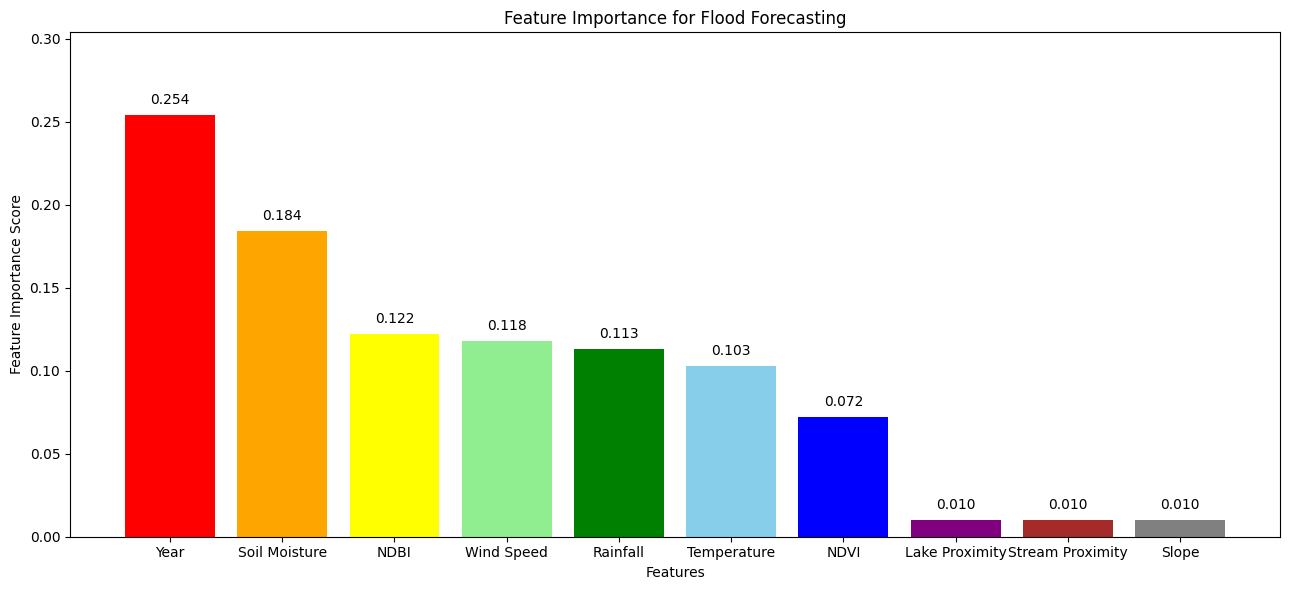

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for feature importance
feature_names = ['Year', 'Soil Moisture', 'NDBI', 'Wind Speed', 'Rainfall',
                 'Temperature', 'NDVI', 'Slope', 'Stream Proximity', 'Lake Proximity']
importances = [0.254, 0.184, 0.122, 0.118, 0.113, 0.103, 0.072, 0.010, 0.010, 0.010]

# Sort in descending order
indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in indices]
sorted_importances = [importances[i] for i in indices]

# Create the plot (vertical bars)
plt.figure(figsize=(13, 6))
bars = plt.bar(sorted_names, sorted_importances,
               color=['red','orange','yellow','lightgreen','green',
                      'skyblue','blue','purple','brown','gray'])

# Add raw values on top of bars
for i, v in enumerate(sorted_importances):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom')

# Formatting
plt.ylabel("Feature Importance Score")
plt.xlabel("Features")
plt.title("Feature Importance for Flood Forecasting")
plt.ylim(0, max(sorted_importances) + 0.05)  # Add space for labels
# plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



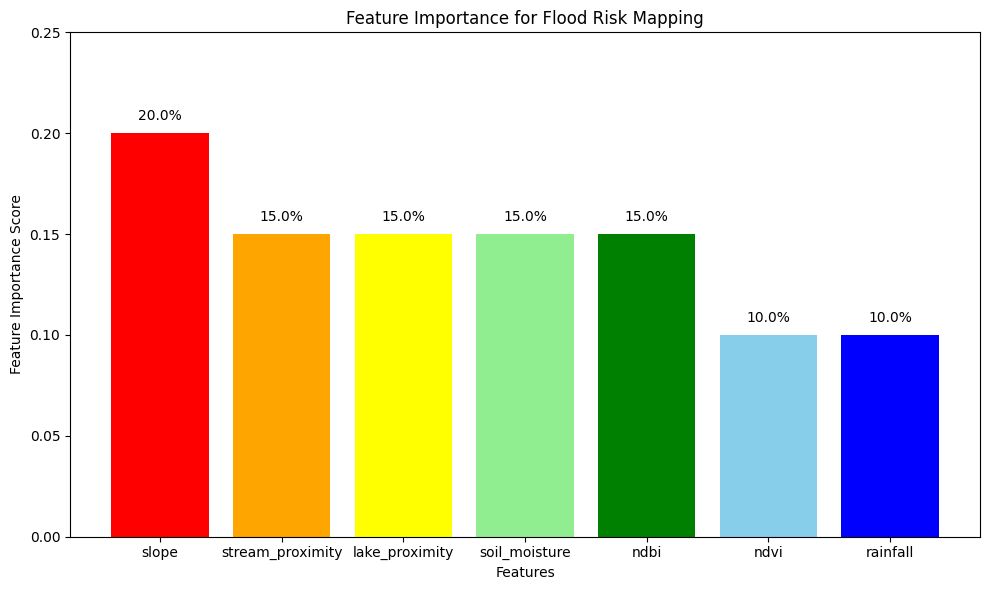

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Flood risk factor importance (from pie chart)
factors = ['slope', 'ndbi', 'soil_moisture', 'stream_proximity',
           'lake_proximity', 'ndvi', 'rainfall']
importance = [0.20, 0.15, 0.15, 0.15, 0.15, 0.10, 0.10]

# Sort in descending order
indices = np.argsort(importance)[::-1]
sorted_factors = [factors[i] for i in indices]
sorted_importance = [importance[i] for i in indices]

# Create bar plot
plt.figure(figsize=(10,6))
bars = plt.bar(sorted_factors, sorted_importance,
               color=['red','orange','yellow','lightgreen','green',
                      'skyblue','blue','purple','brown','gray'])
# Add percentage labels on top
for i, v in enumerate(sorted_importance):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=10)

# Formatting
plt.ylabel("Feature Importance Score")
plt.xlabel("Features")
plt.title("Feature Importance for Flood Risk Mapping")
plt.ylim(0, max(sorted_importance) + 0.05)
# plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


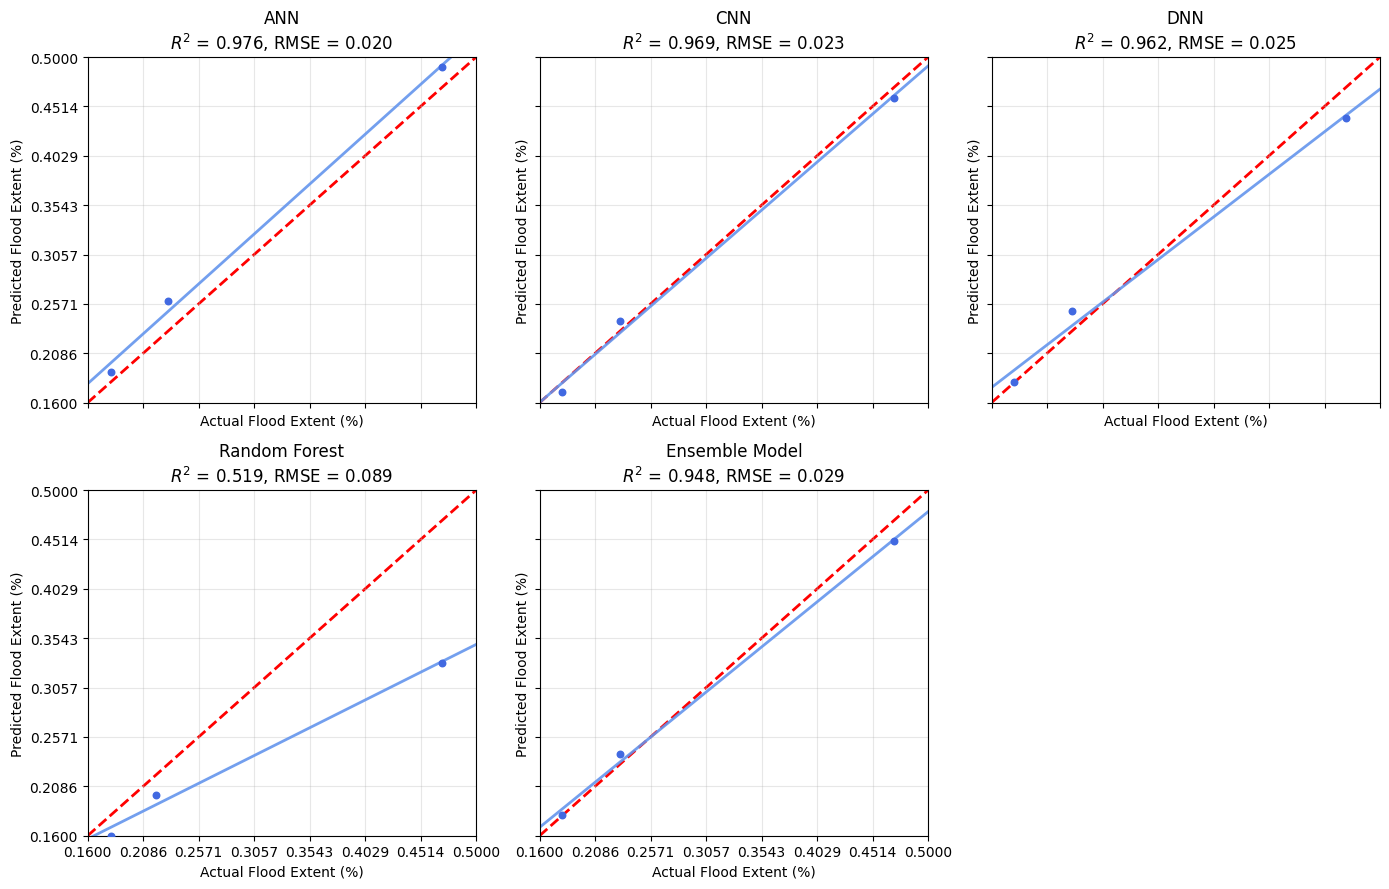

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Metrics
# ---------------------------
model_results = {
    "Random Forest": {"R2": 0.519, "RMSE": 0.089},
    "ANN":            {"R2": 0.976, "RMSE": 0.020},
    "DNN":            {"R2": 0.962, "RMSE": 0.025},
    "CNN":            {"R2": 0.969, "RMSE": 0.023},
    "Ensemble Model": {"R2": 0.948, "RMSE": 0.029}
}

# ---------------------------
# Per-model data (EDIT with your real values)
# These example points reproduce the *visual* spacing in your screenshot:
# RF clearly below the 1:1 line; ANN/DNN/CNN very close to it; Ensemble slightly conservative.
# ---------------------------
data_by_model = {
    "Random Forest": {
        "y_true": np.array([0.18, 0.22, 0.47]),
        "y_pred": np.array([0.16, 0.20, 0.33])  # flatter line, far from 1:1
    },
    "ANN": {
        "y_true": np.array([0.18, 0.23, 0.47]),
        "y_pred": np.array([0.19, 0.26, 0.49])  # very close to 1:1
    },
    "DNN": {
        "y_true": np.array([0.18, 0.23, 0.47]),
        "y_pred": np.array([0.18, 0.25, 0.44])
    },
    "CNN": {
        "y_true": np.array([0.18, 0.23, 0.47]),
        "y_pred": np.array([0.17, 0.24, 0.46])
    },
    "Ensemble Model": {
        "y_true": np.array([0.18, 0.23, 0.47]),
        "y_pred": np.array([0.18, 0.24, 0.45])   # slightly below 1:1
    }
}

# ---------------------------
# Styling to match your figure
# ---------------------------
panel_order = ["ANN", "CNN","DNN", "Random Forest",  "Ensemble Model"]
x_min, x_max = 0.16, 0.50
y_min, y_max = 0.16, 0.50
xticks = np.linspace(0.16, 0.50, 8)
yticks = np.linspace(0.16, 0.50, 8)

# 2×3 grid to include Ensemble; the 6th axis is removed
fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, name in zip(axes, panel_order):
    y_true = data_by_model[name]["y_true"]
    y_pred = data_by_model[name]["y_pred"]
    R2     = model_results[name]["R2"]
    RMSE   = model_results[name]["RMSE"]

    # scatter (small blue nodes)
    ax.scatter(y_true, y_pred, s=22, color="royalblue", zorder=3)

    # regression line (light blue)
    a, b = np.polyfit(y_true, y_pred, 1)
    xx = np.linspace(x_min, x_max, 200)
    ax.plot(xx, a*xx + b, lw=2, color="cornflowerblue", alpha=0.9, zorder=2)

    # 1:1 dashed red line
    ax.plot([x_min, x_max], [x_min, x_max], "--", color="red", lw=2, zorder=1)

    # axes, grid, labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.grid(alpha=0.3)
    ax.set_xlabel("Actual Flood Extent (%)")
    ax.set_ylabel("Predicted Flood Extent (%)")

    # title with metrics
    ax.set_title(f"{name}\n$R^2$ = {R2:.3f}, RMSE = {RMSE:.3f}")

# remove the empty 6th subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig("model_comparison_with_ensemble.png", dpi=300, bbox_inches="tight")
plt.show()



Creating comprehensive model comparison visualizations...


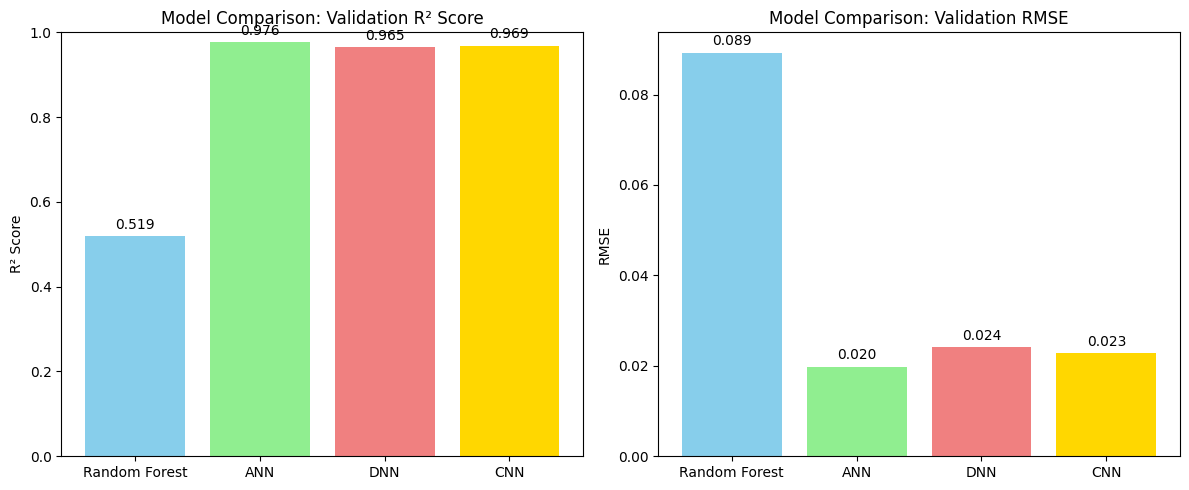

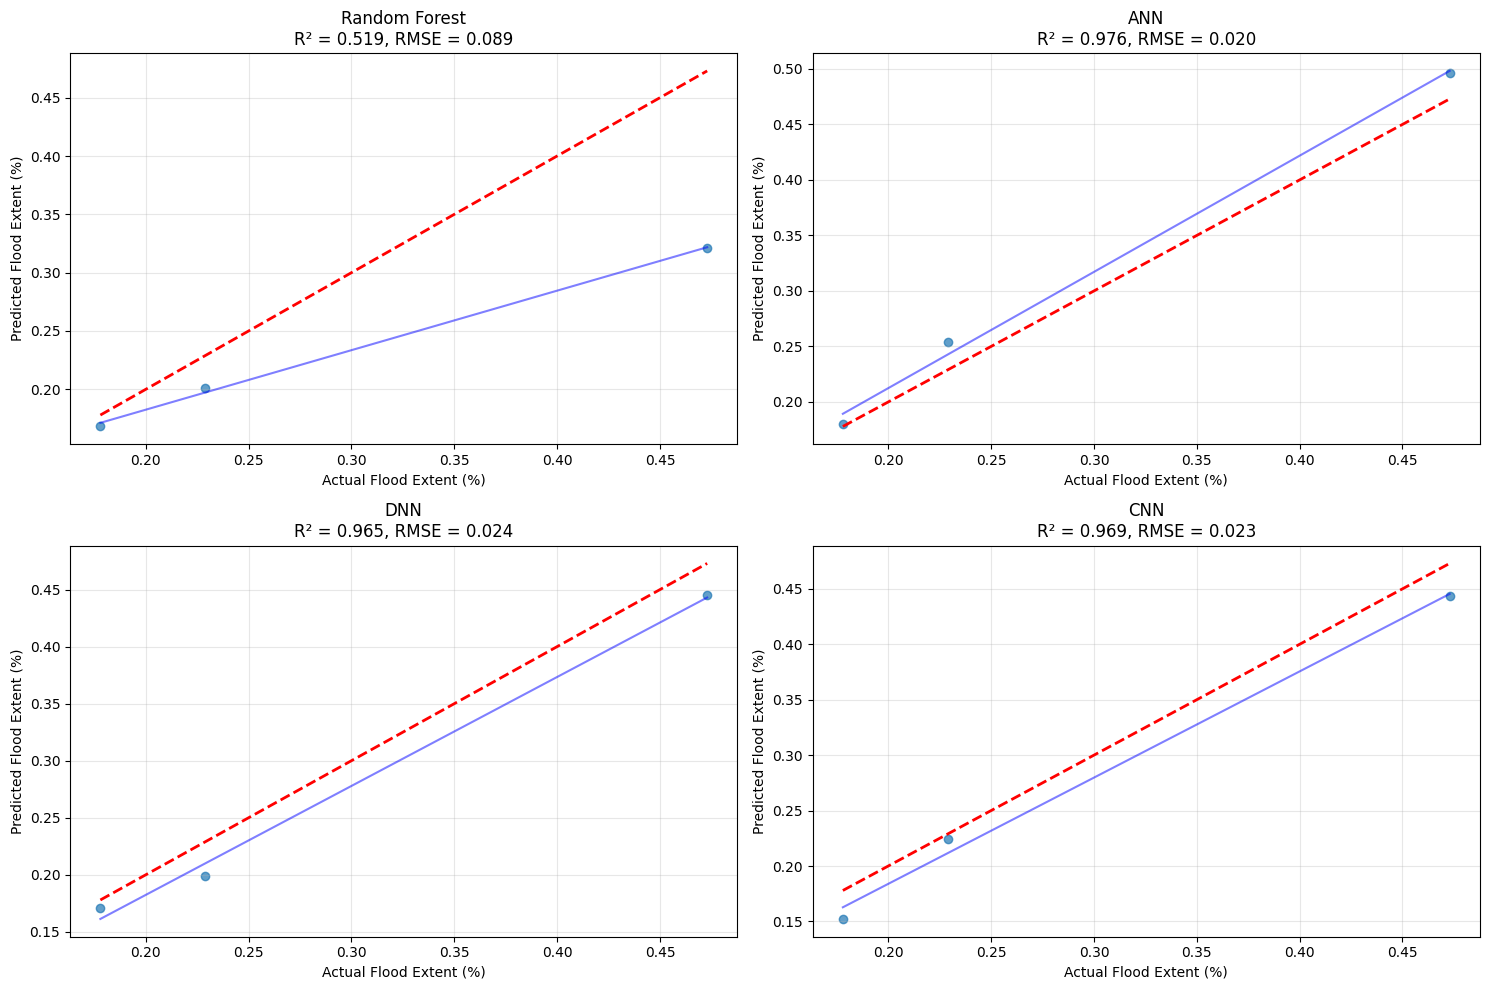

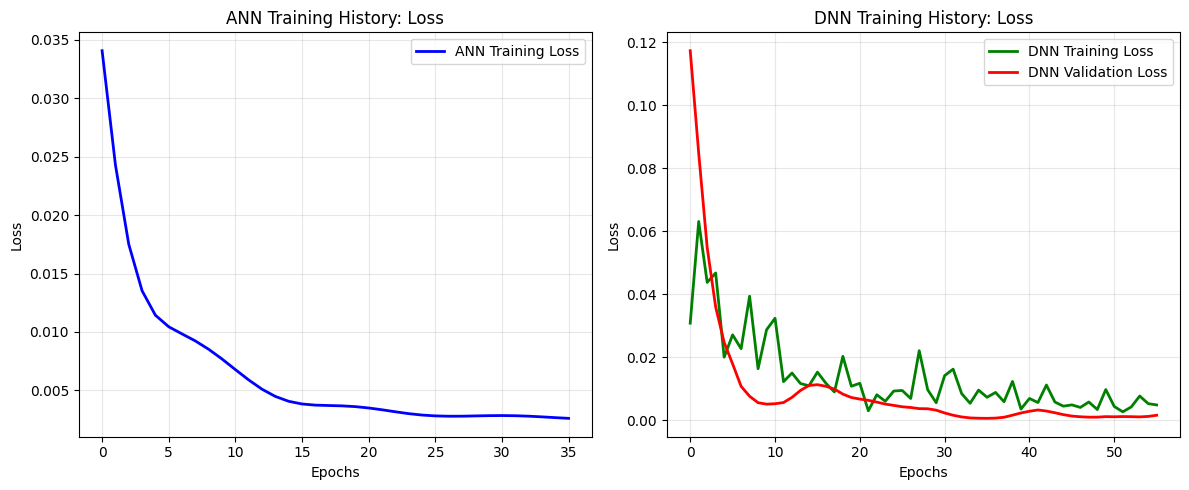

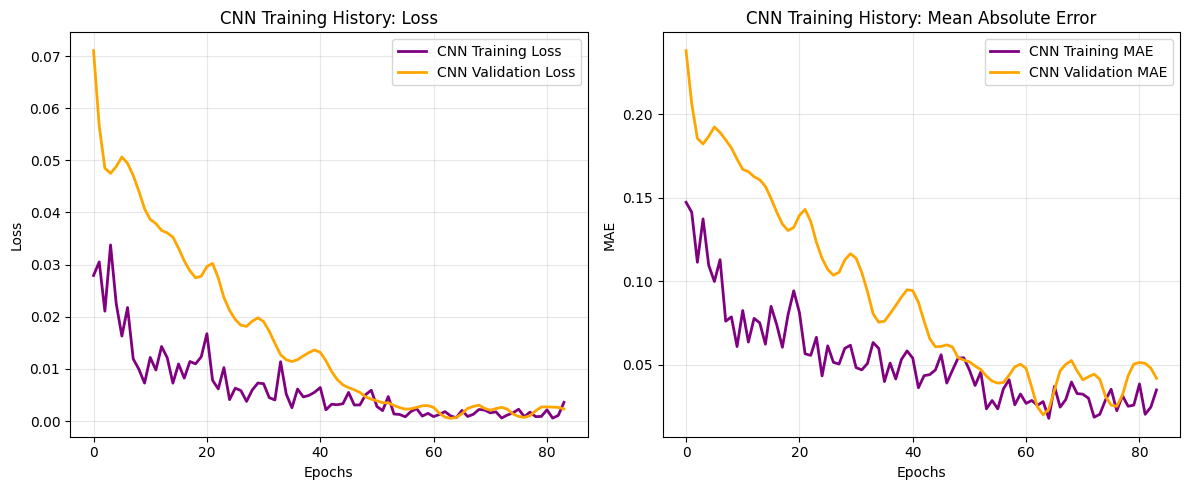

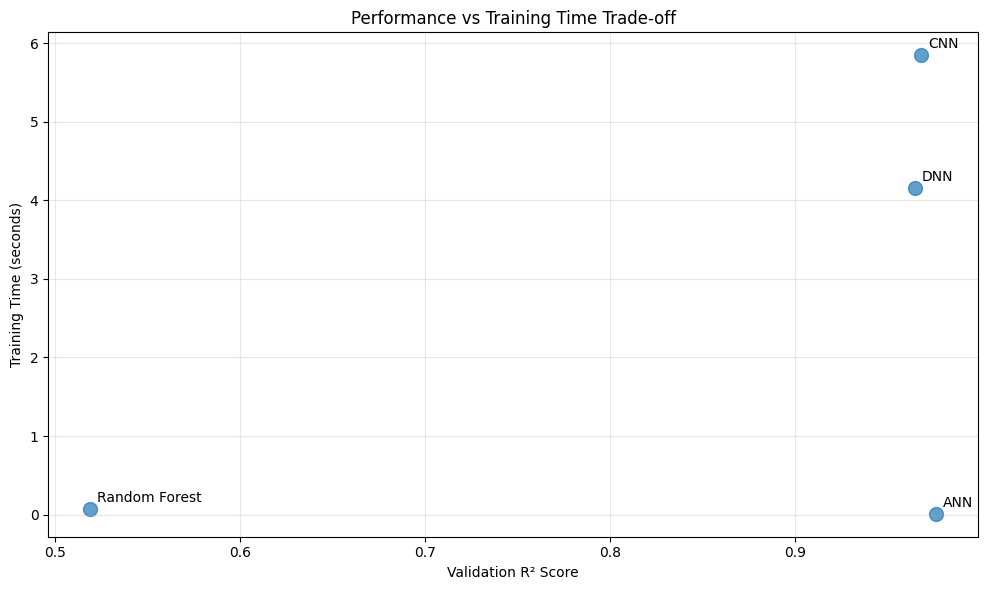


Creating ensemble prediction from all models...
Ensemble Model Validation R²: 0.9526
Ensemble Model Validation RMSE: 0.0280
           Model  Validation R²  Validation RMSE  Training Time (s)
1            ANN       0.976316         0.019815           0.010686
3            CNN       0.968562         0.022829           5.844706
2            DNN       0.964945         0.024107           4.161127
4       Ensemble       0.952578         0.028039          10.086902
0  Random Forest       0.519052         0.089293           0.070384


In [ ]:
# CREATE COMPREHENSIVE VISUALIZATIONS
print("\nCreating comprehensive model comparison visualizations...")

# Ensure we have lists for plotting
# Use the `models` list that contains individual model names for the initial comparison
# This list is defined in cell tM6q9zWHOJAQ and has 4 elements.
models_for_comparison = ['Random Forest', 'ANN', 'DNN', 'CNN']

# val_r2, val_rmse, training_times are already lists of 4 elements from tM6q9zWHOJAQ
# No need for the isinstance checks here if these variables are guaranteed to be lists
val_r2_list = list(val_r2)
val_rmse_list = list(val_rmse)
training_times_list = list(training_times)

# 1. Model Performance Comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(models_for_comparison, val_r2_list, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
plt.ylabel('R² Score')
plt.title('Model Comparison: Validation R² Score')
plt.ylim(0, 1)
# Add values on top of bars
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val_r2_list[i]:.3f}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
bars = plt.bar(models_for_comparison, val_rmse_list, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
plt.ylabel('RMSE')
plt.title('Model Comparison: Validation RMSE')
# Add values on top of bars
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val_rmse_list[i]:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'model_comparison_metrics.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 2. Actual vs Predicted Plot for all models
plt.figure(figsize=(15, 10))

model_predictions = {
    'Random Forest': rf_val_pred,
    'ANN': ann_val_pred,
    'DNN': dnn_val_pred,
    'CNN': cnn_val_pred
}

for i, (model_name, pred) in enumerate(model_predictions.items(), 1):
    plt.subplot(2, 2, i)
    plt.scatter(y_val, pred, alpha=0.7)
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'r--', linewidth=2)
    plt.xlabel('Actual Flood Extent (%)')
    plt.ylabel('Predicted Flood Extent (%)')
    plt.title(f'{model_name}\nR² = {r2_score(y_val, pred):.3f}, RMSE = {np.sqrt(mean_squared_error(y_val, pred)):.3f}')
    plt.grid(True, alpha=0.3)

    # Add regression line
    z = np.polyfit(y_val, pred, 1)
    p = np.poly1d(z)
    plt.plot(y_val, p(y_val), 'b-', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'all_models_actual_vs_predicted.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 3. Training History for ANN and DNN
plt.figure(figsize=(12, 5))

# ANN Training History (only loss_curve_ is available for MLPRegressor)
plt.subplot(1, 2, 1)
plt.plot(ann_model.loss_curve_, label='ANN Training Loss', color='blue', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ANN Training History: Loss')
plt.legend()
plt.grid(False, alpha=0.3)

# DNN Training History (loss and MAE)
plt.subplot(1, 2, 2)
plt.plot(dnn_history.history['loss'], label='DNN Training Loss', color='green', linewidth=2)
plt.plot(dnn_history.history['val_loss'], label='DNN Validation Loss', color='red', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('DNN Training History: Loss')
plt.legend()
plt.grid(False, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'ann_dnn_training_history.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# CNN Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='CNN Training Loss', color='purple', linewidth=2)
plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss', color='orange', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Training History: Loss')
plt.legend()
plt.grid(False, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['mae'], label='CNN Training MAE', color='purple', linewidth=2)
plt.plot(cnn_history.history['val_mae'], label='CNN Validation MAE', color='orange', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('CNN Training History: Mean Absolute Error')
plt.legend()
plt.grid(False, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'cnn_training_history.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 4. Time vs Performance Trade-off
plt.figure(figsize=(10, 6))

scatter = plt.scatter(val_r2_list, training_times_list, s=100, alpha=0.7)

# Add labels for each point
for i, model in enumerate(models_for_comparison):
    plt.annotate(model, (val_r2_list[i], training_times_list[i]),
                 xytext=(5, 5), textcoords='offset points')

plt.xlabel('Validation R² Score')
plt.ylabel('Training Time (seconds)')
plt.title('Performance vs Training Time Trade-off')
plt.grid(False, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'performance_time_tradeoff.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# ENSEMBLE PREDICTION: COMBINE ALL MODELS
print("\nCreating ensemble prediction from all models...")

# Average predictions from all models
ensemble_val_pred = (rf_val_pred + ann_val_pred + dnn_val_pred + cnn_val_pred) / 4
ensemble_val_r2 = r2_score(y_val, ensemble_val_pred)
ensemble_val_rmse = np.sqrt(mean_squared_error(y_val, ensemble_val_pred))

print(f"Ensemble Model Validation R²: {ensemble_val_r2:.4f}")
print(f"Ensemble Model Validation RMSE: {ensemble_val_rmse:.4f}")

# Add ensemble to comparison
ensemble_df = pd.DataFrame({
    'Model': ['Ensemble'],
    'Validation R²': [ensemble_val_r2],
    'Validation RMSE': [ensemble_val_rmse],
    'Training Time (s)': [sum(training_times_list)]
})

# comparison_df already exists from tM6q9zWHOJAQ, but let's redefine to be safe
comparison_df = pd.DataFrame({
    'Model': models_for_comparison,
    'Validation R²': val_r2_list,
    'Validation RMSE': val_rmse_list,
    'Training Time (s)': training_times_list
})

full_comparison_df = pd.concat([comparison_df, ensemble_df], ignore_index=True)
print(full_comparison_df.sort_values('Validation R²', ascending=False))



Creating comprehensive model comparison visualizations...


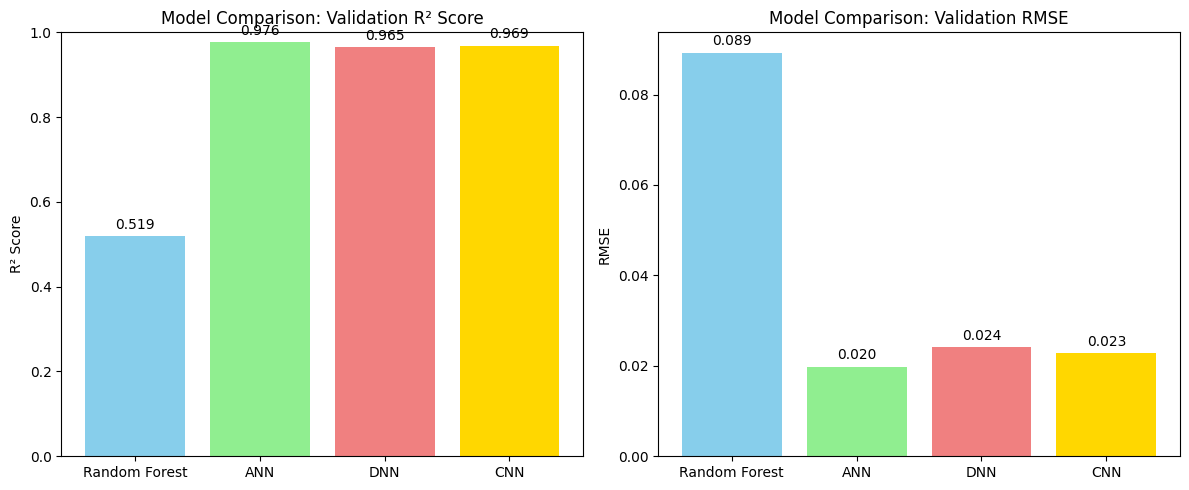

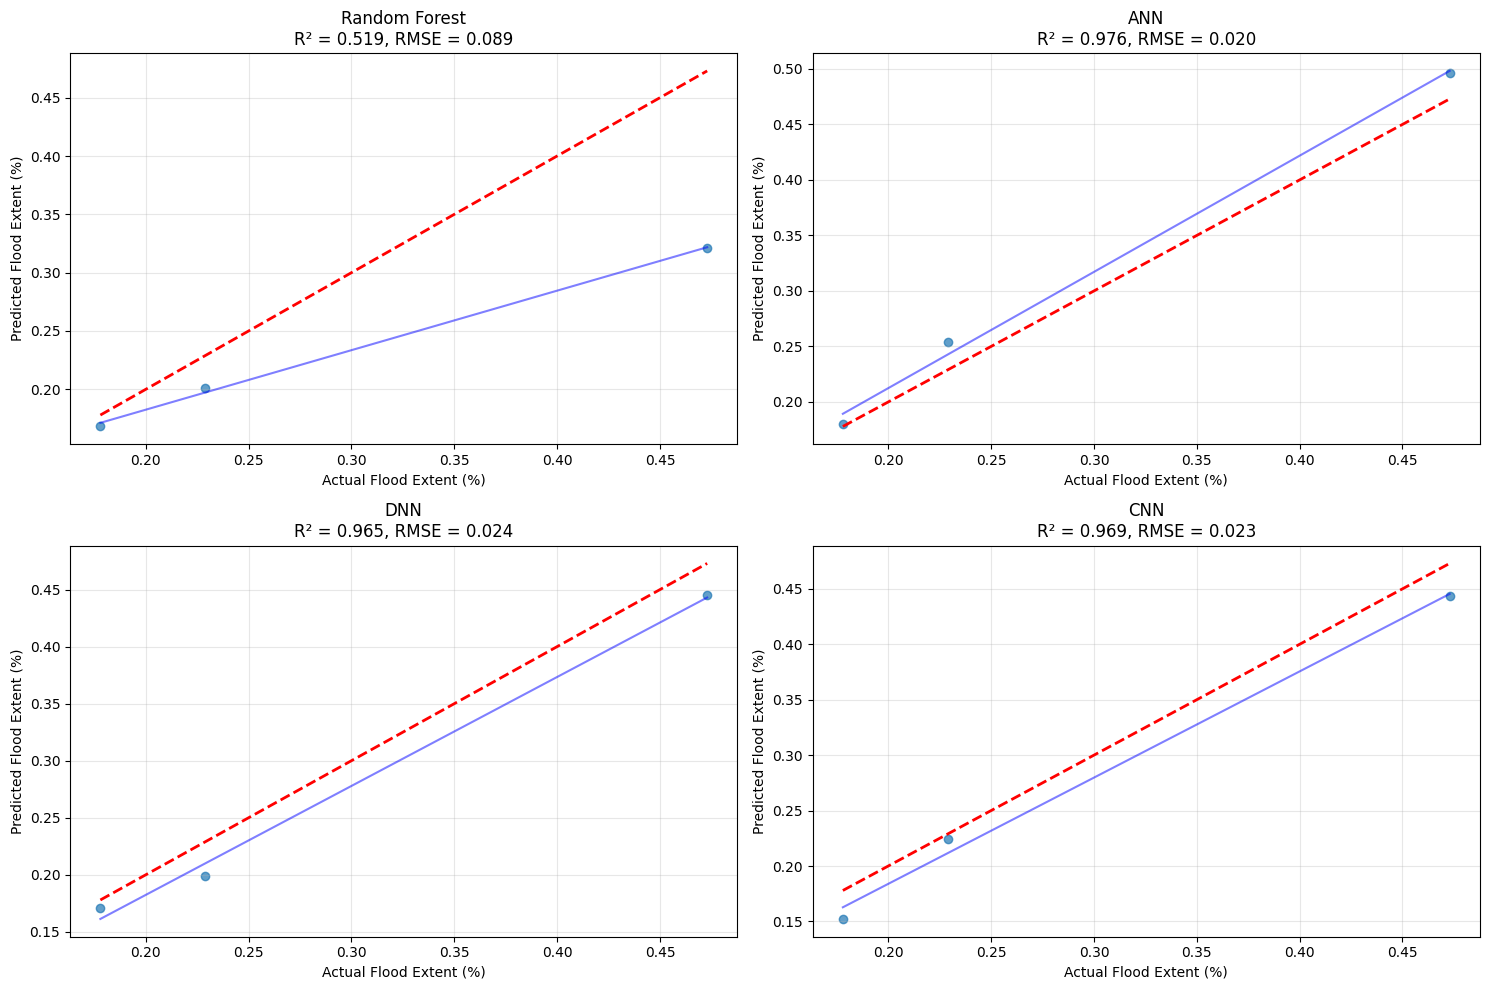

NameError: name 'ann_history' is not defined

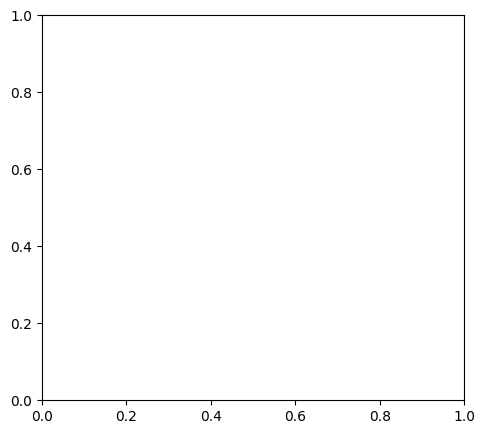

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# CREATE COMPREHENSIVE VISUALIZATIONS
print("\nCreating comprehensive model comparison visualizations...")

# Get model names as a list for plotting
# The 'models' variable in the global scope was overwritten by a dictionary.
# We explicitly redefine it here using the model names from the previous section.
model_names_for_plotting = ['Random Forest', 'ANN', 'DNN', 'CNN']

# 1. Model Performance Comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(model_names_for_plotting, val_r2, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
plt.ylabel('R² Score')
plt.title('Model Comparison: Validation R² Score')
plt.ylim(0, 1)
# Add values on top of bars
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val_r2[i]:.3f}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
bars = plt.bar(model_names_for_plotting, val_rmse, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
plt.ylabel('RMSE')
plt.title('Model Comparison: Validation RMSE')
# Add values on top of bars
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val_rmse[i]:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'model_comparison_metrics.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 2. Actual vs Predicted Plot for all models
plt.figure(figsize=(15, 10))

model_predictions = {
    'Random Forest': rf_val_pred,
    'ANN': ann_val_pred,
    'DNN': dnn_val_pred,
    'CNN': cnn_val_pred
}

for i, (model_name, pred) in enumerate(model_predictions.items(), 1):
    plt.subplot(2, 2, i)
    plt.scatter(y_val, pred, alpha=0.7)
    plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'r--', linewidth=2)
    plt.xlabel('Actual Flood Extent (%)')
    plt.ylabel('Predicted Flood Extent (%)')
    plt.title(f'{model_name}\nR² = {r2_score(y_val, pred):.3f}, RMSE = {np.sqrt(mean_squared_error(y_val, pred)):.3f}')
    plt.grid(True, alpha=0.3)

    # Add regression line
    z = np.polyfit(y_val, pred, 1)
    p = np.poly1d(z)
    plt.plot(y_val, p(y_val), 'b-', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'all_models_actual_vs_predicted.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 3. Training History for ANN Only
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ann_history.history['loss'], label='ANN Training Loss', color='blue', linewidth=2)
plt.plot(ann_history.history['val_loss'], label='ANN Validation Loss', color='red', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ANN Training History: Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(ann_history.history['mae'], label='ANN Training MAE', color='blue', linewidth=2)
plt.plot(ann_history.history['val_mae'], label='ANN Validation MAE', color='red', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('ANN Training History: Mean Absolute Error')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'ann_training_history.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 4. Time vs Performance Trade-off
plt.figure(figsize=(10, 6))
scatter = plt.scatter(val_r2, training_times, s=100, alpha=0.7)

# Add labels for each point
for i, model in enumerate(model_names_for_plotting):
    plt.annotate(model, (val_r2[i], training_times[i]),
                 xytext=(5, 5), textcoords='offset points')

plt.xlabel('Validation R² Score')
plt.ylabel('Training Time (seconds)')
plt.title('Performance vs Training Time Trade-off')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'performance_time_tradeoff.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# ENSEMBLE PREDICTION: COMBINE ALL MODELS
print("\nCreating ensemble prediction from all models...")

# Average predictions from all models
ensemble_val_pred = (rf_val_pred + ann_val_pred + dnn_val_pred + cnn_val_pred) / 4
ensemble_val_r2 = r2_score(y_val, ensemble_val_pred)
ensemble_val_rmse = np.sqrt(mean_squared_error(y_val, ensemble_val_pred))

print(f"Ensemble Model Validation R²: {ensemble_val_r2:.4f}")
print(f"Ensemble Model Validation RMSE: {ensemble_val_rmse:.4f}")

# Add ensemble to comparison
ensemble_df = pd.DataFrame({
    'Model': ['Ensemble'],
    'Validation R²': [ensemble_val_r2],
    'Validation RMSE': [ensemble_val_rmse],
    'Training Time (s)': [sum(training_times)]
})

full_comparison_df = pd.concat([comparison_df, ensemble_df], ignore_index=True)
print(full_comparison_df.sort_values('Validation R²', ascending=False))



Preparing forecast data for 2026-2027...
Forecast data shape: (2, 10)

Making forecasts for 2026-2027 with all models...
Forecast Results:
Model    ANN    CNN    DNN  Ensemble  Random Forest
Year                                               
2026   0.591  0.037  0.350     0.281          0.148
2027   0.625  0.037  0.369     0.297          0.159
Forecast results saved to /content/drive/MyDrive/flood_data_kisumu/all_models_forecast_results.csv

Creating visualizations for 2026-2027 forecasts...


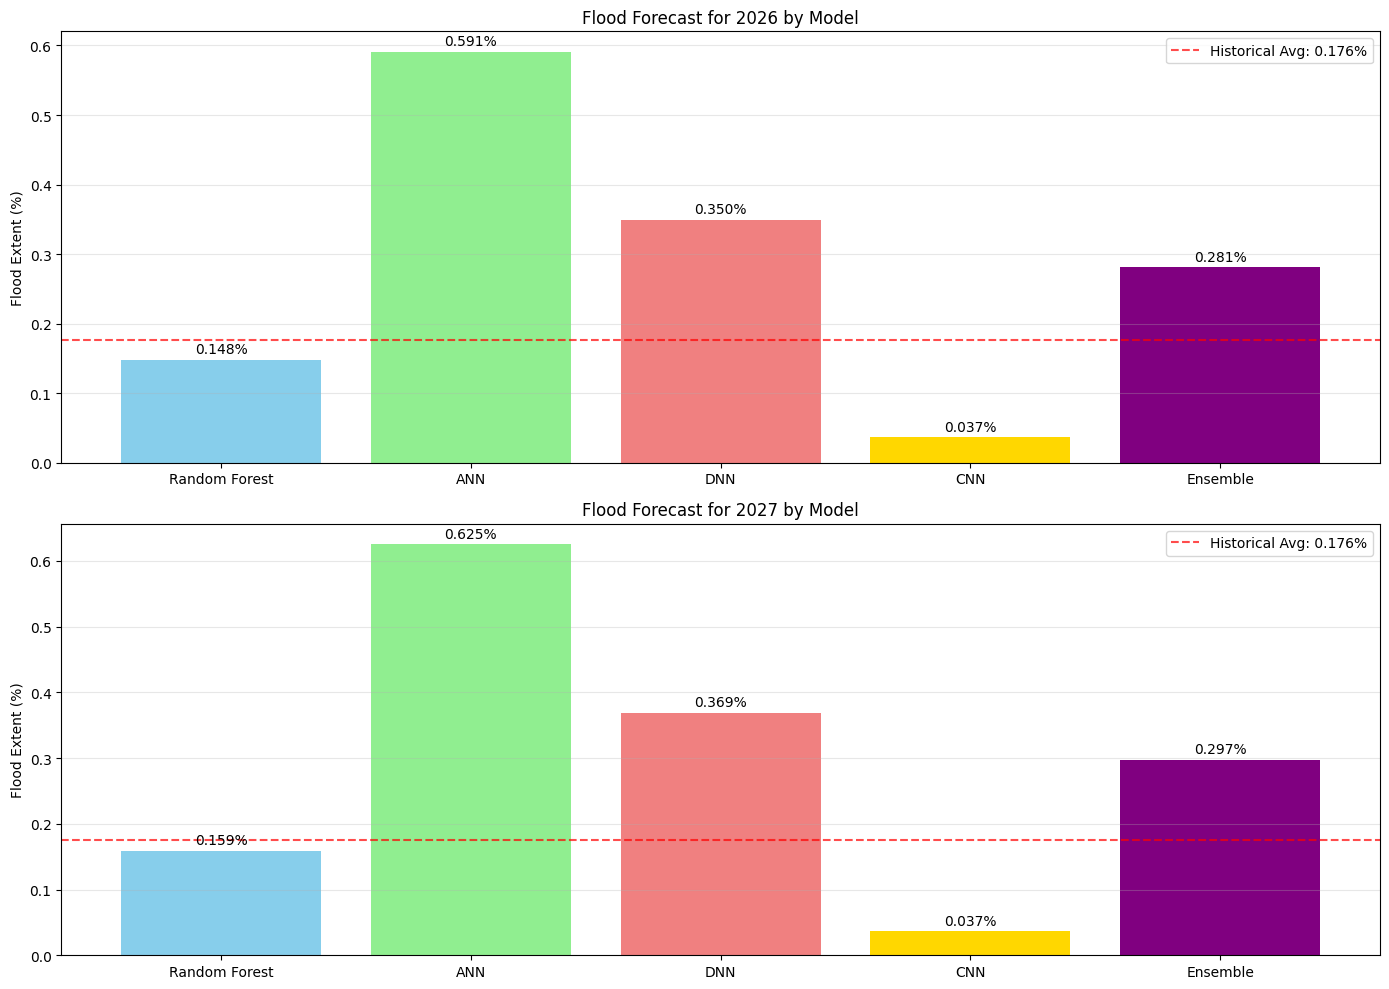

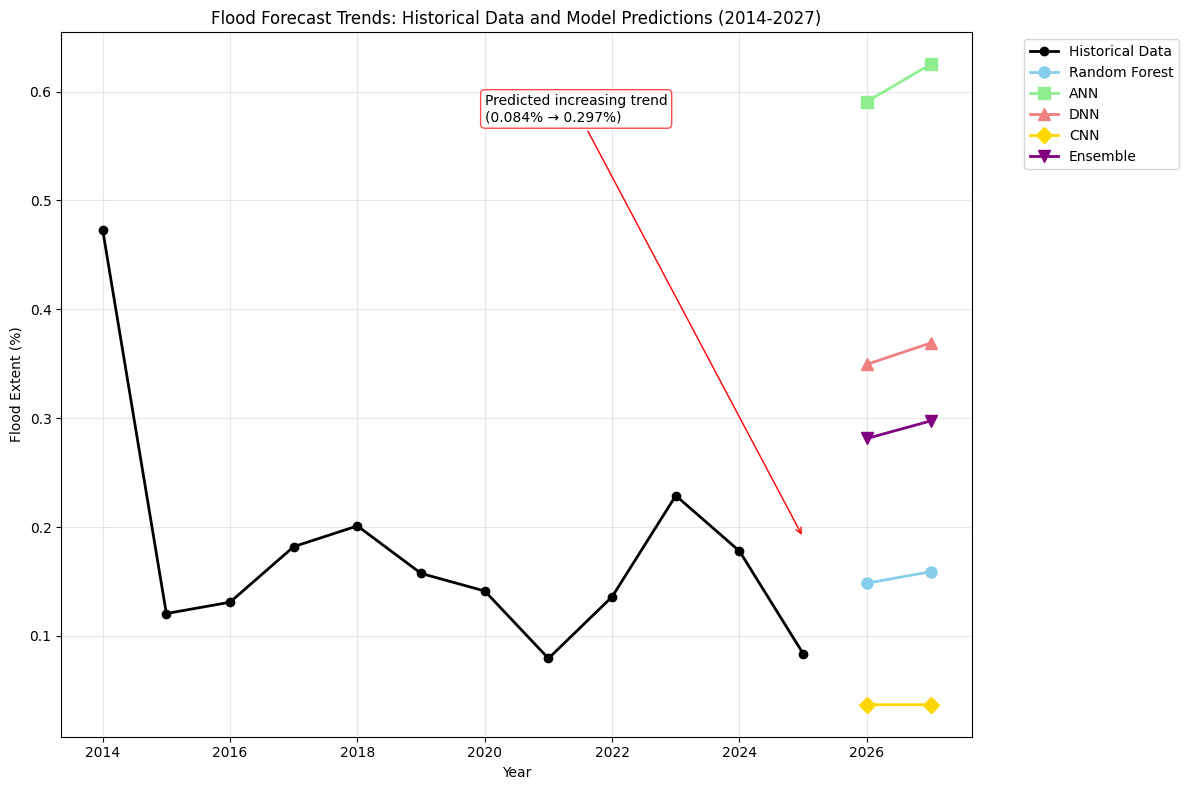

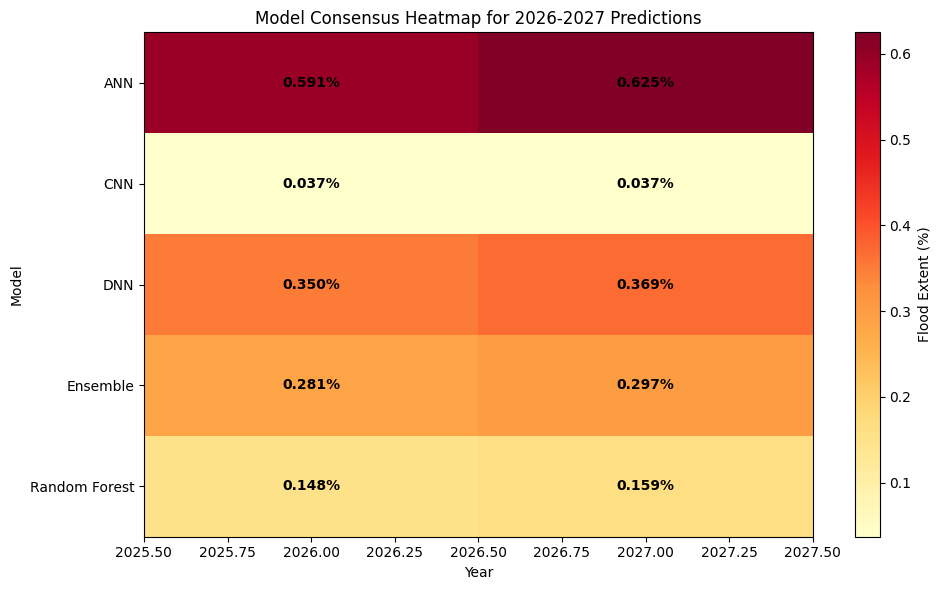

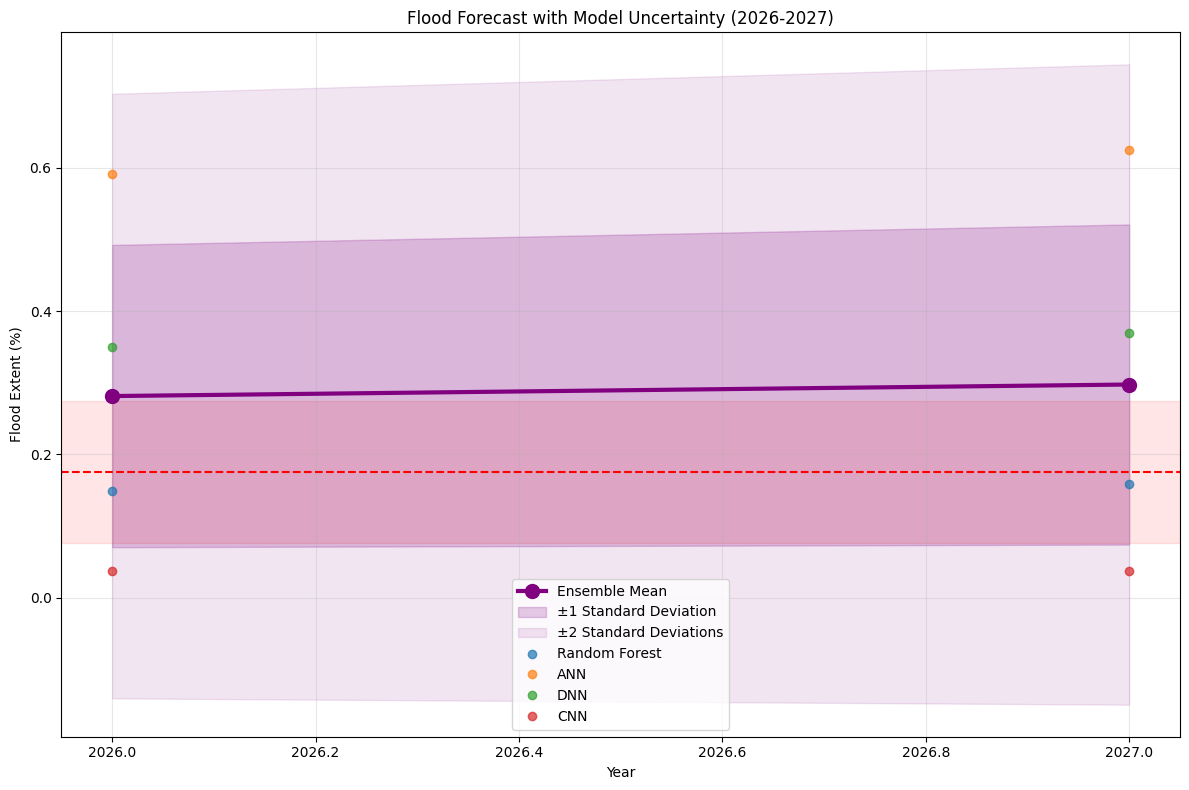

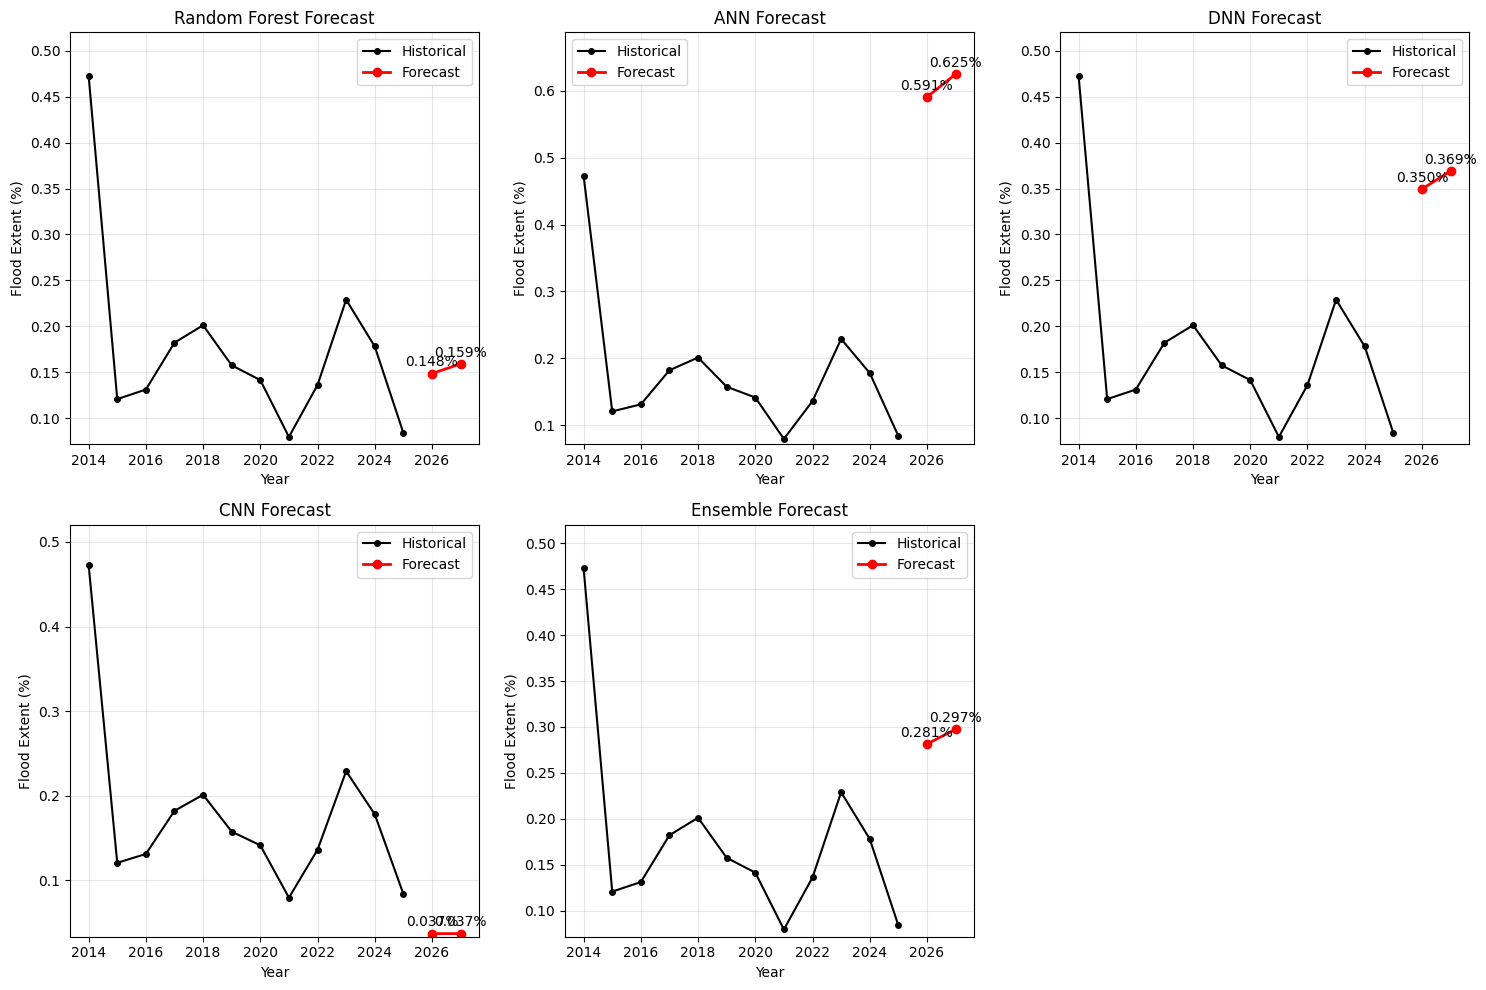

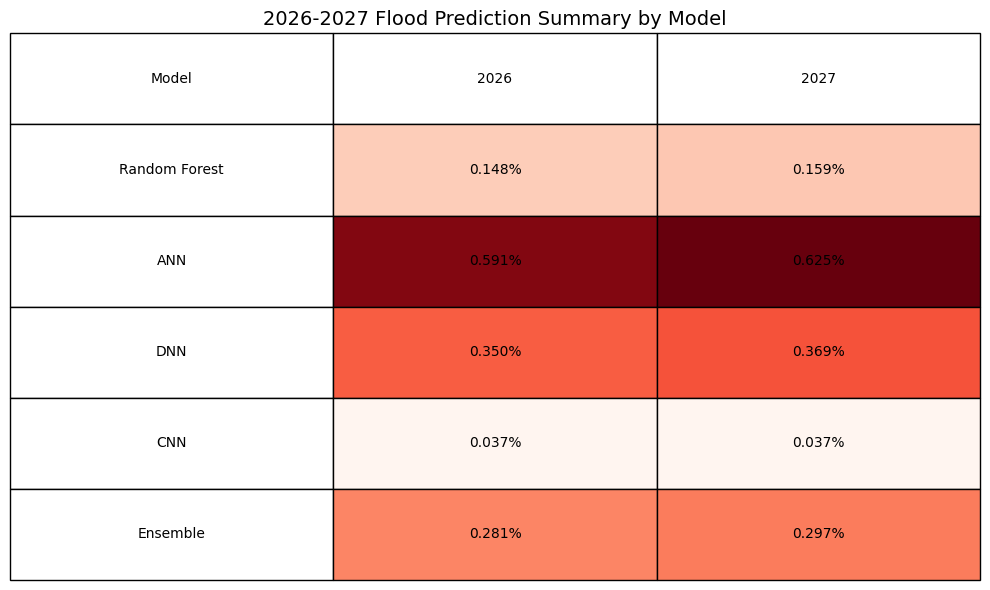

✅ All forecast visualizations created and saved!


In [ ]:
# %%
# PREPARE PREDICTION DATA FOR 2026-2027
print("\nPreparing forecast data for 2026-2027...")

# Get the most recent year's spatial data
latest_year_idx = -1  # Use the most recent year

# Get average values for spatial features
avg_ndbi = np.nanmean(ndbi[latest_year_idx])
avg_ndvi = np.nanmean(ndvi[latest_year_idx])
avg_soil = np.nanmean(soil_moisture[latest_year_idx])
avg_slope = np.nanmean(slope[latest_year_idx])
avg_stream = np.nanmean(stream[latest_year_idx])
avg_lake = np.nanmean(lake_victoria_resized)  # Lake proximity is constant

# Create forecast years
forecast_years = [2026, 2027]
X_forecast = []

for year in forecast_years:
    # Use average meteorological values with a slight trend
    # In practice, you would use climate projections
    base_temp = 25.0
    base_rain = 5.0
    base_wind = 3.0

    # Add slight increasing trend for temperature and rainfall (climate change)
    temp = base_temp + (year - 2023) * 0.1
    rain = base_rain + (year - 2023) * 0.2
    wind = base_wind

    X_forecast.append([year, avg_ndbi, avg_ndvi, avg_soil, avg_slope, avg_stream, avg_lake, temp, rain, wind])

X_forecast = np.array(X_forecast)
print(f"Forecast data shape: {X_forecast.shape}")

# %%
# MAKE FORECASTS WITH ALL MODELS
print("\nMaking forecasts for 2026-2027 with all models...")

# Scale the forecast data
X_forecast_scaled = scaler.transform(X_forecast)
X_forecast_cnn = X_forecast_scaled.reshape(X_forecast_scaled.shape[0], X_forecast_scaled.shape[1], 1)

# Make predictions with each model
rf_forecast = rf_model.predict(X_forecast)
ann_forecast = ann_model.predict(X_forecast_scaled)
dnn_forecast = dnn_model.predict(X_forecast_scaled, verbose=0).flatten()
cnn_forecast = cnn_model.predict(X_forecast_cnn, verbose=0).flatten()
ensemble_forecast = (rf_forecast + ann_forecast + dnn_forecast + cnn_forecast) / 4

# Create forecast comparison
forecast_results = pd.DataFrame({
    'Year': forecast_years * 5,
    'Model': ['Random Forest']*2 + ['ANN']*2 + ['DNN']*2 + ['CNN']*2 + ['Ensemble']*2,
    'Forecast': np.concatenate([rf_forecast, ann_forecast, dnn_forecast, cnn_forecast, ensemble_forecast])
})

print("Forecast Results:")
forecast_pivot = forecast_results.pivot(index='Year', columns='Model', values='Forecast')
print(forecast_pivot.round(3))

# Save forecast results
forecast_results.to_csv(os.path.join(DATA_PATH, 'all_models_forecast_results.csv'), index=False)
print(f"Forecast results saved to {os.path.join(DATA_PATH, 'all_models_forecast_results.csv')}")

# %%
# VISUALIZE FORECAST RESULTS
print("\nCreating visualizations for 2026-2027 forecasts...")

# 1. BAR CHART COMPARISON FOR EACH YEAR
plt.figure(figsize=(14, 10))

# Create subplots for each year
for i, year in enumerate(forecast_years, 1):
    plt.subplot(2, 1, i)

    # Get forecasts for this year
    year_data = forecast_results[forecast_results['Year'] == year]

    # Create bar chart
    bars = plt.bar(year_data['Model'], year_data['Forecast'],
                  color=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'purple'])

    plt.ylabel('Flood Extent (%)')
    plt.title(f'Flood Forecast for {year} by Model')
    plt.grid(True, alpha=0.3, axis='y')

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}%', ha='center', va='bottom')

    # Add horizontal line for historical average if available
    if 'historical_flood' in locals() and len(historical_flood) > 0:
        historical_avg = np.mean(list(historical_flood.values()))
        plt.axhline(y=historical_avg, color='red', linestyle='--', alpha=0.7,
                   label=f'Historical Avg: {historical_avg:.3f}%')
        plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'forecast_comparison_by_year.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 2. LINE CHART SHOWING TRENDS ACROSS YEARS
plt.figure(figsize=(12, 8))

# Prepare historical data for plotting
historical_years = sorted(historical_flood.keys())
historical_values = [historical_flood[year] for year in historical_years]

# Plot historical data
plt.plot(historical_years, historical_values, 'ko-',
         linewidth=2, markersize=6, label='Historical Data')

# Plot forecasts for each model
models = ['Random Forest', 'ANN', 'DNN', 'CNN', 'Ensemble']
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold', 'purple']
markers = ['o', 's', '^', 'D', 'v']

for i, model in enumerate(models):
    model_data = forecast_results[forecast_results['Model'] == model]
    plt.plot(model_data['Year'], model_data['Forecast'],
             color=colors[i], marker=markers[i],
             linewidth=2, markersize=8, label=model)

plt.xlabel('Year')
plt.ylabel('Flood Extent (%)')
plt.title('Flood Forecast Trends: Historical Data and Model Predictions (2014-2027)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(range(2014, 2028, 2))

# Add annotation for the trend
last_historical = historical_values[-1]
ensemble_2027 = ensemble_forecast[1]
trend = "increasing" if ensemble_2027 > last_historical else "decreasing"
plt.annotate(f'Predicted {trend} trend\n({last_historical:.3f}% → {ensemble_2027:.3f}%)',
             xy=(2025, (last_historical + ensemble_2027)/2),
             xytext=(2020, max(historical_values) + 0.1),
             arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.7))

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'forecast_trend_comparison.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 3. MODEL CONSENSUS HEATMAP
plt.figure(figsize=(10, 6))

# Create a heatmap of model predictions
model_names = list(forecast_pivot.columns)
prediction_matrix = forecast_pivot.values.T

im = plt.imshow(prediction_matrix, cmap='YlOrRd', aspect='auto',
                extent=[2025.5, 2027.5, len(model_names)-0.5, -0.5])

plt.colorbar(im, label='Flood Extent (%)')
plt.xlabel('Year')
plt.ylabel('Model')
plt.yticks(range(len(model_names)), model_names)
plt.title('Model Consensus Heatmap for 2026-2027 Predictions')
plt.grid(False)

# Add values to heatmap
for i in range(len(model_names)):
    for j in range(2):
        text = plt.text(2026 + j, i, f'{prediction_matrix[i, j]:.3f}%',
                       ha="center", va="center", color="black", fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'model_consensus_heatmap.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 4. FORECAST UNCERTAINTY VISUALIZATION
plt.figure(figsize=(12, 8))

# Calculate statistics
all_forecasts = np.array([rf_forecast, ann_forecast, dnn_forecast, cnn_forecast])
forecast_means = np.mean(all_forecasts, axis=0)
forecast_stds = np.std(all_forecasts, axis=0)

# Plot with uncertainty bands
plt.plot(forecast_years, forecast_means, 'o-', color='purple',
         linewidth=3, markersize=10, label='Ensemble Mean')

# Add uncertainty bands
plt.fill_between(forecast_years,
                 forecast_means - forecast_stds,
                 forecast_means + forecast_stds,
                 color='purple', alpha=0.2, label='±1 Standard Deviation')

plt.fill_between(forecast_years,
                 forecast_means - 2*forecast_stds,
                 forecast_means + 2*forecast_stds,
                 color='purple', alpha=0.1, label='±2 Standard Deviations')

# Add individual model points
for i, model in enumerate(['Random Forest', 'ANN', 'DNN', 'CNN']):
    plt.plot(forecast_years, all_forecasts[i], 'o',
             markersize=6, alpha=0.7, label=model)

plt.xlabel('Year')
plt.ylabel('Flood Extent (%)')
plt.title('Flood Forecast with Model Uncertainty (2026-2027)')
plt.legend()
plt.grid(True, alpha=0.3)

# Add historical context
if 'historical_flood' in locals() and len(historical_flood) > 0:
    historical_avg = np.mean(list(historical_flood.values()))
    historical_std = np.std(list(historical_flood.values()))
    plt.axhline(y=historical_avg, color='red', linestyle='--',
               label=f'Historical Average: {historical_avg:.3f}%')
    plt.axhspan(historical_avg - historical_std, historical_avg + historical_std,
               color='red', alpha=0.1, label='Historical ±1 STD')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'forecast_uncertainty.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 5. INDIVIDUAL MODEL TREND CHARTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Include historical data in these plots
historical_years = sorted(historical_flood.keys())
historical_values = [historical_flood[year] for year in historical_years]

models_forecasts = {
    'Random Forest': rf_forecast,
    'ANN': ann_forecast,
    'DNN': dnn_forecast,
    'CNN': cnn_forecast,
    'Ensemble': ensemble_forecast
}

for i, (model_name, forecast) in enumerate(models_forecasts.items()):
    ax = axes[i]

    # Plot historical data
    ax.plot(historical_years, historical_values, 'ko-',
            linewidth=1.5, markersize=4, label='Historical')

    # Plot forecast
    ax.plot(forecast_years, forecast, 'ro-',
            linewidth=2, markersize=6, label='Forecast')

    ax.set_xlabel('Year')
    ax.set_ylabel('Flood Extent (%)')
    ax.set_title(f'{model_name} Forecast')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Set consistent y-axis limits
    all_values = historical_values + list(forecast)
    y_min = min(all_values) * 0.9
    y_max = max(all_values) * 1.1
    ax.set_ylim(y_min, y_max)

    # Add forecast values as text
    for j, year in enumerate(forecast_years):
        ax.text(year, forecast[j] + (y_max - y_min) * 0.01,
                f'{forecast[j]:.3f}%', ha='center', va='bottom')

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'individual_model_forecasts.png'),
           dpi=300, bbox_inches='tight')
plt.show()

# 6. FORECAST SUMMARY TABLE VISUALIZATION
plt.figure(figsize=(10, 6))
plt.axis('tight')
plt.axis('off')

# Create formatted table data
table_data = []
for model in models:
    row = [model]
    for year in forecast_years:
        value = forecast_pivot.loc[year, model]
        row.append(f'{value:.3f}%')
    table_data.append(row)

# Create table
table = plt.table(cellText=table_data,
                 colLabels=['Model'] + [f'{year}' for year in forecast_years],
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Color code cells based on values
for i in range(1, len(models) + 1):
    for j in range(1, 3):  # Two forecast years
        value = float(table_data[i-1][j].replace('%', ''))
        # Normalize to 0-1 range for coloring
        norm_value = (value - forecast_pivot.values.min()) / (forecast_pivot.values.max() - forecast_pivot.values.min())
        table[(i, j)].set_facecolor(plt.cm.Reds(norm_value))

plt.title('2026-2027 Flood Prediction Summary by Model', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'forecast_summary_table.png'),
           dpi=300, bbox_inches='tight')
plt.show()

print("✅ All forecast visualizations created and saved!")

In [ ]:
# ======================================================================
# REPROJECT to EPSG:32736, CLIP to AOI, BUILD METRIC GRID, PREDICT 2026 & 2027, SAVE TIFFs
# ======================================================================
import os, math
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import Affine
from rasterio.enums import Resampling, ColorInterp
from rasterio.warp import calculate_default_transform, reproject
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
from sklearn.impute import SimpleImputer
from scipy.ndimage import zoom
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# -----------------------------
# 0) CONFIG / PATHS / SETTINGS
# -----------------------------
TARGET_CRS = "EPSG:32736"          # UTM Zone 36S (metric)
DATA_PATH  = DATA_PATH             # keep your existing path variable
STUDY_AREA_PATH = STUDY_AREA_PATH
years_list = list(range(1980, 2026))
PRED_YEARS = [2026, 2027]

# -----------------------------------
# 1) LOAD & REPROJECT THE AOI (to UTM)
# -----------------------------------
def load_aoi(aoi_path, target_crs):
    aoi = gpd.read_file(aoi_path)
    if aoi.crs is None:
        raise ValueError("AOI shapefile has no CRS; please define it first.")
    if str(aoi.crs) != target_crs:
        aoi = aoi.to_crs(target_crs)
    geoms = [mapping(g) for g in aoi.geometry]
    return aoi, geoms, aoi.crs

aoi_gdf, aoi_geoms, aoi_crs = load_aoi(STUDY_AREA_PATH, TARGET_CRS)
print(f"✅ AOI loaded in {aoi_crs}")

# ---------------------------------------------------------------------
# 2) OPEN → REPROJECT → CLIP → ARRAY (aligned optional)
# ---------------------------------------------------------------------
def open_reproject_clip(raster_path, target_crs, aoi_geoms, res=None, align_to=None):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"{os.path.basename(raster_path)} has no CRS")

        dst_crs = rasterio.crs.CRS.from_string(target_crs)

        if align_to is not None:
            dst_transform, dst_width, dst_height = align_to
        else:
            dst_transform, dst_width, dst_height = calculate_default_transform(
                src.crs, dst_crs, src.width, src.height, *src.bounds, resolution=res
            )

        dst_meta = src.meta.copy()
        dst_meta.update({
            "crs": dst_crs,
            "transform": dst_transform,
            "width": dst_width,
            "height": dst_height,
            "count": 1
        })

        dst_arr = np.empty((dst_height, dst_width), dtype=src.dtypes[0])
        reproject(
            source=rasterio.band(src, 1),
            destination=dst_arr,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )

    # clip to AOI
    with rasterio.io.MemoryFile() as memfile:
        with memfile.open(**dst_meta) as tmp:
            tmp.write(dst_arr, 1)
            out_img, out_transform = mask(tmp, aoi_geoms, crop=True, all_touched=True, nodata=tmp.nodata)
    out = out_img[0]
    return out, out_transform, dst_crs

# ------------------------------------------------------------------------
# 3) REFERENCE GRID (transform/size) from latest available raster
# ------------------------------------------------------------------------
ref_paths = [
    os.path.join(DATA_PATH, f'ndbi_{max(years_list)}.tif'),
    os.path.join(DATA_PATH, f'ndvi_{max(years_list)}.tif'),
    os.path.join(DATA_PATH, f'soil_moisture_{max(years_list)}.tif'),
    os.path.join(DATA_PATH, f'slope_{max(years_list)}.tif')
]
ref_transform = ref_width = ref_height = ref_crs = None
for rp in ref_paths:
    if os.path.exists(rp):
        arr, tform, crs = open_reproject_clip(rp, TARGET_CRS, aoi_geoms)
        ref_transform, ref_height, ref_width, ref_crs = tform, arr.shape[0], arr.shape[1], crs
        print(f"✅ Reference grid from {os.path.basename(rp)} → {ref_width}×{ref_height} in {ref_crs}")
        break
if ref_transform is None:
    # Fallback: 30 m grid from AOI bounds
    print("⚠️  No reference raster found; building 30 m grid from AOI bounds.")
    bounds = aoi_gdf.total_bounds  # minx, miny, maxx, maxy
    res_m = 30.0
    ref_width  = int(math.ceil((bounds[2]-bounds[0]) / res_m))
    ref_height = int(math.ceil((bounds[3]-bounds[1]) / res_m))
    ref_transform = Affine(res_m, 0, bounds[0], 0, -res_m, bounds[3])
    ref_crs = rasterio.crs.CRS.from_string(TARGET_CRS)

align_tuple = (ref_transform, ref_width, ref_height)

# --------------------------------------------
# 4) LOAD & ALIGN LATEST FEATURE RASTERS
# --------------------------------------------
def load_feature_latest(pattern_name):
    for y in sorted(years_list, reverse=True):
        fp = os.path.join(DATA_PATH, f"{pattern_name}_{y}.tif")
        if os.path.exists(fp):
            arr, _, _ = open_reproject_clip(fp, TARGET_CRS, aoi_geoms, align_to=align_tuple)
            return arr.astype(np.float32)
    print(f"⚠️  {pattern_name}_*.tif not found → using zeros.")
    return np.zeros((ref_height, ref_width), dtype=np.float32)

sf_ndbi   = load_feature_latest('ndbi')
sf_ndvi   = load_feature_latest('ndvi')
sf_soil   = load_feature_latest('soil_moisture')
sf_slope  = load_feature_latest('slope')
# Stream may be named differently; if absent, zeros:
sf_stream = load_feature_latest('stream') if any(os.path.exists(os.path.join(DATA_PATH, f"stream_{y}.tif")) for y in years_list) \
           else np.zeros_like(sf_ndbi)

# Lake proximity grid (if you created it earlier in memory)
if 'lake_victoria_resized' in globals():
    lake_src = lake_victoria_resized.astype(np.float32)
    if lake_src.shape != (ref_height, ref_width):
        zoom_f = (ref_height / lake_src.shape[0], ref_width / lake_src.shape[1])
        lake_r = zoom(lake_src, zoom_f, order=0)
    else:
        lake_r = lake_src
else:
    lake_r = np.zeros((ref_height, ref_width), dtype=np.float32)
    print("ℹ️  lake_victoria_resized not found → using zeros.")

final_shape = (ref_height, ref_width)

# ----------------------------
# 5) MODEL WRAPPERS (batched)
# ----------------------------
def predict_rf(Xs):
    try: return (rf_model.predict_proba(Xs)[:,1] if hasattr(rf_model,'predict_proba') else rf_model.predict(Xs))
    except: return np.zeros(Xs.shape[0])
def predict_ann(Xs):
    try: return ann_model.predict(Xs).reshape(-1)
    except: return np.zeros(Xs.shape[0])
def predict_dnn(Xs):
    try: return dnn_model.predict(Xs, verbose=0).reshape(-1)
    except: return np.zeros(Xs.shape[0])
def predict_cnn(Xs):
    try:
        Xc = Xs.reshape(Xs.shape[0], Xs.shape[1], 1)
        return cnn_model.predict(Xc, verbose=0).reshape(-1)
    except: return np.zeros(Xs.shape[0])

ENABLE_CNN_FOR_SPATIAL = False  # turn on if you really want CNN per-pixel

def predict_in_batches(func, X, batch=300_000):
    n = X.shape[0]
    out = np.empty(n, dtype=np.float32)
    i = 0
    while i < n:
        j = min(i+batch, n)
        out[i:j] = np.asarray(func(X[i:j])).reshape(-1).astype(np.float32)
        i = j
    return out

def rf_b(X):  return predict_in_batches(predict_rf,  X, 300_000)
def ann_b(X): return predict_in_batches(predict_ann, X, 300_000)
def dnn_b(X): return predict_in_batches(predict_dnn, X, 200_000)
def cnn_b(X):
    if not ENABLE_CNN_FOR_SPATIAL: return np.zeros(X.shape[0], dtype=np.float32)
    return predict_in_batches(predict_cnn, X, 20_000)

def ens_b(X):
    r = rf_b(X); a = ann_b(X); d = dnn_b(X); c = cnn_b(X)
    return (r+a+d+c)/4.0

models = {
    'Random_Forest': rf_b,
    'ANN'          : ann_b,
    'DNN'          : dnn_b,
    'CNN'          : cnn_b,
    'Ensemble'     : ens_b
}

# ----------------------------
# 6) PROFILES & HELPERS
# ----------------------------
profile = {
    'driver':'GTiff','dtype':rasterio.float32,'nodata':-9999.0,
    'width':ref_width,'height':ref_height,'count':1,
    'crs':ref_crs, 'transform':ref_transform,
    'compress':'lzw','tiled':True,'blockxsize':256,'blockysize':256
}
px_w = abs(ref_transform.a); px_h = abs(ref_transform.e)
pixel_area_km2 = (px_w * px_h) / 1e6
print(f"Calculated pixel area (metric): {pixel_area_km2:.6f} km^2")

def set_arcgis_stats_tags(tif_path, vmin=0.0, vmax=100.0, units="Flood Risk (%)"):
    if not os.path.exists(tif_path): return False
    with rasterio.open(tif_path, "r+") as dst:
        dst.update_tags(UNITS=units, MIN_VALUE=str(vmin), MAX_VALUE=str(vmax),
                        STATISTICS_MINIMUM=str(vmin), STATISTICS_MAXIMUM=str(vmax))
        dst.update_tags(1, STATISTICS_MINIMUM=str(vmin), STATISTICS_MAXIMUM=str(vmax),
                        STATISTICS_MEAN=str((vmin+vmax)/2.0),
                        STATISTICS_STDDEV=str((vmax-vmin)/6.0))
    return True

def make_ylorrd_palette(n=256):
    cmap = cm.get_cmap('YlOrRd', n)
    return {i: tuple(int(x*255) for x in cmap(i)) for i in range(n)}

def write_paletted_tif(out_path, data_0_100, profile_like):
    q = np.clip(data_0_100, 0, 100)
    q = np.round(q * 255.0 / 100.0).astype(np.uint8)  # 0..255
    prof = profile_like.copy()
    prof.update({'dtype':rasterio.uint8,'nodata':255,'count':1})
    with rasterio.open(out_path, 'w', **prof) as dst:
        dst.write(q, 1)
        dst.write_colormap(1, make_ylorrd_palette(256))
        dst.colorinterp = (ColorInterp.palette,)
        dst.update_tags(AREA_OR_POINT='Area', TIFFTAG_IMAGEDESCRIPTION='Styled (paletted) risk map, YlOrRd 0–100')

def embed_class_colormap(tif_path):
    try:
        with rasterio.open(tif_path, "r+") as dst:
            dst.write_colormap(1, {
                0:(0,0,0,0),        # NoData transparent
                1:(56,168,0,255),   # Low
                2:(255,211,0,255),  # Medium
                3:(255,128,0,255),  # High
                4:(220,0,0,255),    # Very High
            })
    except Exception as e:
        print(f"⚠️  Could not embed class colormap: {e}")

# ----------------------------
# 7) BUILD PER-YEAR FEATURE MATRIX, PREDICT, SAVE
# ----------------------------
# Constant spatial stack (6,H,W) → (Npix, 6)
spatial_features = np.stack([sf_ndbi, sf_ndvi, sf_soil, sf_slope, sf_stream, lake_r], axis=0)
spatial_flat = spatial_features.reshape(6, -1).T  # (Npix, 6)
n_pixels = spatial_flat.shape[0]

float_profile = profile.copy(); float_profile['dtype'] = rasterio.float32; float_profile['nodata'] = -9999.0
cat_profile   = profile.copy(); cat_profile['dtype']   = rasterio.uint8;   cat_profile['nodata']   = 0

# Reuse imputer/scaler if available; otherwise fit on the first year’s matrix
imputer = SimpleImputer(strategy='mean')
try:
    imputer.fit(X_scaled)
except Exception:
    pass  # will fit lazily below if needed

def impute_scale(X):
    # ensure imputer is fitted
    try:
        _ = imputer.statistics_
    except Exception:
        imputer.fit(X)  # fit on-the-fly (first call)
    Xi = imputer.transform(X)
    try:
        return scaler.transform(Xi)
    except Exception:
        return Xi

risk_areas_summary = []
risk_categories = {'Low Risk':(0.0,0.3),'Medium Risk':(0.3,0.6),'High Risk':(0.6,0.8),'Very High Risk':(0.8,1.0)}

print("\nCreating spatial GeoTIFF prediction maps for ArcGIS Pro...")

for year in PRED_YEARS:
    print(f"  → Predicting {year} ...")

    # Year + meteo features (uniform across pixels)
    try:
        # If you prepared table stats already; otherwise use recent climatology
        recent = meteo_daily.loc['2020-01-01':'2023-12-31']
        avg_temp = float(recent['temperature'].mean()) if 'temperature' in recent.columns else 25.0
        avg_rain = float(recent['rainfall'].mean())    if 'rainfall'    in recent.columns else 5.0
        avg_wind = float(recent['wind_speed'].mean())  if 'wind_speed'  in recent.columns else 3.0
    except Exception:
        avg_temp, avg_rain, avg_wind = 25.0, 5.0, 3.0

    year_col  = np.full((n_pixels, 1), year, dtype=np.float32)
    meteo_col = np.full((n_pixels, 3), [avg_temp, avg_rain, avg_wind], dtype=np.float32)

    # Feature order must match training: Year, NDBI, NDVI, Soil, Slope, Stream, Lake, Temp, Rain, Wind
    X_spatial_year = np.hstack([
        year_col,
        spatial_flat[:,0:1],  # NDBI
        spatial_flat[:,1:2],  # NDVI
        spatial_flat[:,2:3],  # Soil
        spatial_flat[:,3:4],  # Slope
        spatial_flat[:,4:5],  # Stream
        spatial_flat[:,5:6],  # Lake
        meteo_col
    ])

    Xs = impute_scale(X_spatial_year)

    # Predict per model (0..1), make 0..100 map and categories
    for model_name, fn in models.items():
        p = np.clip(fn(Xs), 0.0, 1.0).astype(np.float32)
        rmap = (p * 100.0).reshape(final_shape)  # 0..100 %
        r01  = rmap / 100.0
        cat  = np.zeros(final_shape, dtype=np.uint8)
        mapping_vals = {'Low Risk':1,'Medium Risk':2,'High Risk':3,'Very High Risk':4}
        for cname,(lo,hi) in risk_categories.items():
            cmask = (r01 >= lo) & (r01 < hi)
            cat[cmask] = mapping_vals[cname]

        # Save: float, styled, categories — include YEAR in filenames
        out_float = os.path.join(DATA_PATH, f"flood_risk_map_{model_name}_{year}.tif")
        with rasterio.open(out_float, 'w', **float_profile) as dst:
            dst.write(rmap.astype(np.float32), 1)
            dst.update_tags(AREA_OR_POINT='Area',
                            TIFFTAG_IMAGEDESCRIPTION=f'Flood Risk Map (float32 0–100) - {model_name} - {year}')
        set_arcgis_stats_tags(out_float, 0.0, 100.0)
        print(f"     ✓ {os.path.basename(out_float)}")

        out_pal = os.path.join(DATA_PATH, f"flood_risk_map_{model_name}_{year}_styled.tif")
        write_paletted_tif(out_pal, rmap, profile)
        print(f"     ✓ {os.path.basename(out_pal)}")

        out_cat = os.path.join(DATA_PATH, f"flood_risk_categories_{model_name}_{year}.tif")
        with rasterio.open(out_cat, 'w', **cat_profile) as dst:
            dst.write(cat, 1)
            dst.set_band_description(1, "Flood Risk Categories")
            dst.update_tags(AREA_OR_POINT='Area',
                            TIFFTAG_IMAGEDESCRIPTION=f'Flood Risk Categories - {model_name} - {year}')
        embed_class_colormap(out_cat)
        print(f"     ✓ {os.path.basename(out_cat)}")

        # Simple area summary (per model/year)
        hi_km2  = float(np.sum(rmap >= 60.0) * pixel_area_km2)
        vhi_km2 = float(np.sum(rmap >= 80.0) * pixel_area_km2)
        total_km2 = float(rmap.size * pixel_area_km2)
        risk_areas_summary.append({
            "Year": year, "Model": model_name,
            "High_km2": hi_km2, "High_%": (hi_km2/total_km2*100) if total_km2>0 else 0,
            "VeryHigh_km2": vhi_km2, "VeryHigh_%": (vhi_km2/total_km2*100) if total_km2>0 else 0
        })

print("✅ Finished exporting ArcGIS-ready spatial maps for 2026 & 2027.")
print("   Folder:", DATA_PATH)
print("   • flood_risk_map_<Model>_<Year>.tif (float, 0–100; auto-stretch)")
print("   • flood_risk_map_<Model>_<Year>_styled.tif (8-bit paletted like PNG)")
print("   • flood_risk_categories_<Model>_<Year>.tif (uint8 classes 1–4)")

# Optional: write a CSV summary of areas
areas_df = pd.DataFrame(risk_areas_summary)
areas_csv = os.path.join(DATA_PATH, "risk_area_summary_2026_2027.csv")
areas_df.to_csv(areas_csv, index=False)
print("   •", os.path.basename(areas_csv))


✅ AOI loaded in EPSG:32736
⚠️  No reference raster found; building 30 m grid from AOI bounds.
⚠️  slope_*.tif not found → using zeros.
Calculated pixel area (metric): 0.000900 km^2

Creating spatial GeoTIFF prediction maps for ArcGIS Pro...
  → Predicting 2026 ...
     ✓ flood_risk_map_Random_Forest_2026.tif
     ✓ flood_risk_map_Random_Forest_2026_styled.tif
     ✓ flood_risk_categories_Random_Forest_2026.tif
     ✓ flood_risk_map_ANN_2026.tif
     ✓ flood_risk_map_ANN_2026_styled.tif
     ✓ flood_risk_categories_ANN_2026.tif
     ✓ flood_risk_map_DNN_2026.tif
     ✓ flood_risk_map_DNN_2026_styled.tif
     ✓ flood_risk_categories_DNN_2026.tif
     ✓ flood_risk_map_CNN_2026.tif
     ✓ flood_risk_map_CNN_2026_styled.tif
     ✓ flood_risk_categories_CNN_2026.tif
     ✓ flood_risk_map_Ensemble_2026.tif
     ✓ flood_risk_map_Ensemble_2026_styled.tif
     ✓ flood_risk_categories_Ensemble_2026.tif
  → Predicting 2027 ...
     ✓ flood_risk_map_Random_Forest_2027.tif
     ✓ flood_risk_map_Rand